# 🎯 The Complete Guide to Regularization

**Master every concept, formula, and intuition — interview-ready.**

---

## Table of Contents

1. [What is Regularization & Why Do We Need It?](#1)
2. [The Bias-Variance Tradeoff](#2)
3. [L2 Regularization (Ridge)](#3)
4. [L1 Regularization (Lasso)](#4)
5. [L1 vs L2: Geometric Intuition](#5)
6. [Elastic Net (L1 + L2)](#6)
7. [Regularization in Neural Networks](#7)
    - Dropout
    - Batch Normalization
    - Weight Decay
    - Early Stopping
    - Data Augmentation
8. [Bayesian Interpretation](#8)
9. [Interview Questions & Answers](#9)

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Consistent styling
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#0f0f1a',
    'axes.edgecolor': '#3a3a5c',
    'axes.labelcolor': '#c0c0e0',
    'text.color': '#c0c0e0',
    'xtick.color': '#8080a0',
    'ytick.color': '#8080a0',
    'grid.color': '#2a2a4a',
    'font.family': 'monospace',
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 120
})

# Color palette
C = {
    'blue':    '#4fc3f7',
    'orange':  '#ffb74d',
    'green':   '#81c784',
    'red':     '#ef5350',
    'purple':  '#ce93d8',
    'yellow':  '#fff176',
    'cyan':    '#4dd0e1',
    'pink':    '#f48fb1',
    'white':   '#e0e0f0',
    'gray':    '#8080a0',
}

print("✅ Setup complete. Let's learn regularization!")

✅ Setup complete. Let's learn regularization!


<a id='1'></a>
## 1. What is Regularization & Why Do We Need It?

**Regularization** is any technique that constrains or penalizes a model to prevent **overfitting**.

### The Core Problem

When we train a model, we minimize a **loss function** on training data:

$$\hat{\theta} = \arg\min_{\theta} \; \mathcal{L}(\theta; X_{\text{train}}, y_{\text{train}})$$

But minimizing training loss perfectly can lead to **overfitting** — the model memorizes noise instead of learning the true pattern. It performs great on training data but terribly on unseen data.

### The Regularization Idea

Add a **penalty term** $\Omega(\theta)$ that discourages complexity:

$$\hat{\theta} = \arg\min_{\theta} \; \underbrace{\mathcal{L}(\theta)}_\text{data fit} + \underbrace{\lambda \, \Omega(\theta)}_\text{complexity penalty}$$

where $\lambda \geq 0$ controls the **regularization strength**:
- $\lambda = 0$: No regularization (pure data fit)
- $\lambda \to \infty$: Ignores data, maximally simple model

Let's see this in action.

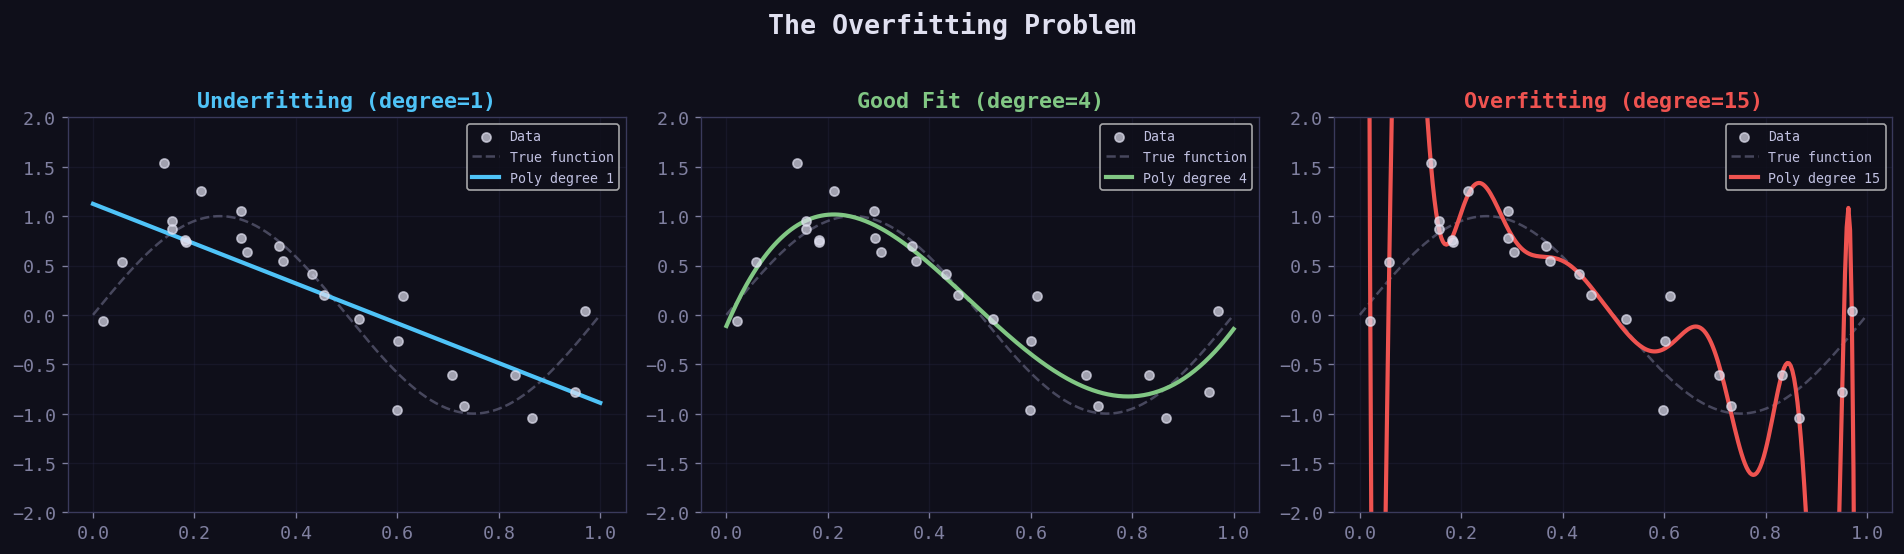

In [2]:
# Generate noisy data from a simple sine curve
np.random.seed(42)
n = 25
X = np.sort(np.random.uniform(0, 1, n))
y_true = np.sin(2 * np.pi * X)
y = y_true + np.random.normal(0, 0.3, n)

X_plot = np.linspace(0, 1, 300)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

titles = ['Underfitting (degree=1)', 'Good Fit (degree=4)', 'Overfitting (degree=15)']
degrees = [1, 4, 15]
colors = [C['blue'], C['green'], C['red']]

for ax, deg, title, color in zip(axes, degrees, titles, colors):
    model = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    model.fit(X.reshape(-1, 1), y)
    y_pred = model.predict(X_plot.reshape(-1, 1))
    
    ax.scatter(X, y, c=C['white'], s=30, alpha=0.7, zorder=5, label='Data')
    ax.plot(X_plot, np.sin(2 * np.pi * X_plot), '--', c=C['gray'], alpha=0.5, label='True function')
    ax.plot(X_plot, y_pred, c=color, lw=2.5, label=f'Poly degree {deg}')
    ax.set_title(title, fontsize=13, fontweight='bold', color=color)
    ax.set_ylim(-2, 2)
    ax.legend(fontsize=8, loc='upper right')

fig.suptitle('The Overfitting Problem', fontsize=16, fontweight='bold', color=C['white'], y=1.02)
plt.tight_layout()
plt.show()

<a id='2'></a>
## 2. The Bias-Variance Tradeoff

For any model, the **expected test error** decomposes as:

$$\mathbb{E}\left[(y - \hat{f}(x))^2\right] = \underbrace{\text{Bias}^2(\hat{f})}_\text{underfitting} + \underbrace{\text{Var}(\hat{f})}_\text{overfitting} + \underbrace{\sigma^2}_\text{irreducible noise}$$

| Term | Meaning | When it's high |
|------|---------|----------------|
| **Bias²** | Error from wrong assumptions | Model too simple |
| **Variance** | Sensitivity to training data | Model too complex |
| **σ²** | Noise in the data | Always present, can't reduce |

**Regularization increases bias slightly but reduces variance significantly**, often lowering total error.

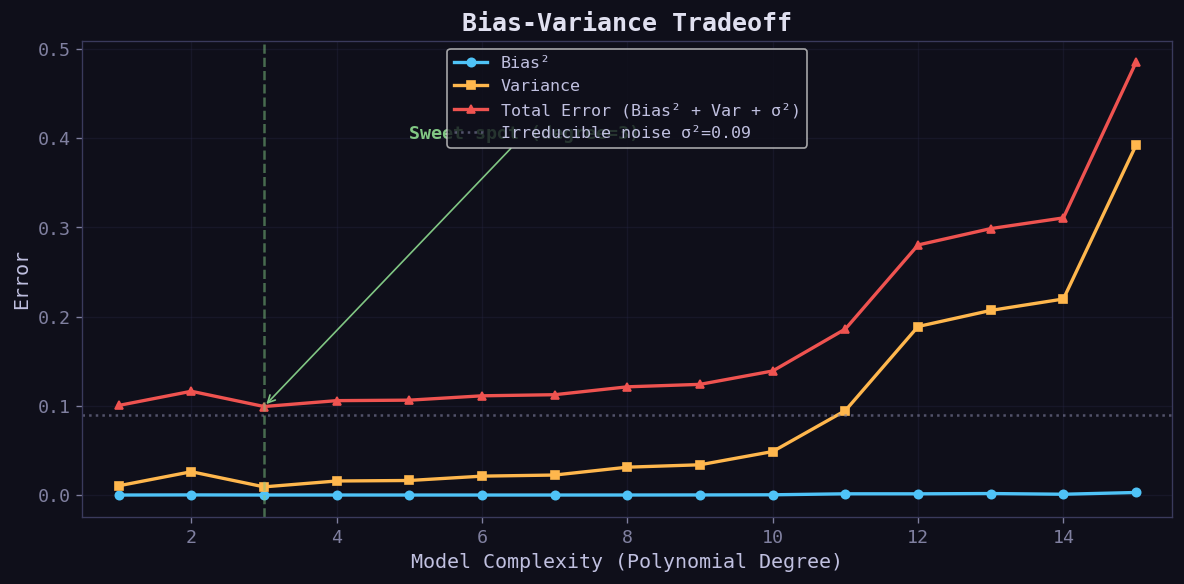

In [3]:
# Simulate the Bias-Variance Tradeoff
np.random.seed(0)
n_experiments = 200
n_samples = 25
degrees = range(1, 16)

# True function
f_true = lambda x: np.sin(2 * np.pi * x)
x_test = 0.5  # evaluate at a single test point

predictions = {d: [] for d in degrees}

for _ in range(n_experiments):
    X_train = np.random.uniform(0, 1, n_samples)
    y_train = f_true(X_train) + np.random.normal(0, 0.3, n_samples)
    
    for d in degrees:
        model = make_pipeline(PolynomialFeatures(d), LinearRegression())
        model.fit(X_train.reshape(-1, 1), y_train)
        pred = model.predict([[x_test]])[0]
        predictions[d].append(pred)

# Compute bias² and variance
true_val = f_true(x_test)
bias_sq = [( np.mean(predictions[d]) - true_val )**2 for d in degrees]
variance = [np.var(predictions[d]) for d in degrees]
noise = 0.3**2
total_error = [b + v + noise for b, v in zip(bias_sq, variance)]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(list(degrees), bias_sq, 'o-', c=C['blue'], lw=2, label='Bias²', markersize=5)
ax.plot(list(degrees), variance, 's-', c=C['orange'], lw=2, label='Variance', markersize=5)
ax.plot(list(degrees), total_error, '^-', c=C['red'], lw=2, label='Total Error (Bias² + Var + σ²)', markersize=5)
ax.axhline(noise, ls=':', c=C['gray'], alpha=0.6, label=f'Irreducible noise σ²={noise:.2f}')

best_d = list(degrees)[np.argmin(total_error)]
ax.axvline(best_d, ls='--', c=C['green'], alpha=0.5)
ax.annotate(f'Sweet spot (degree={best_d})', xy=(best_d, min(total_error)),
            xytext=(best_d + 2, min(total_error) + 0.3),
            arrowprops=dict(arrowstyle='->', color=C['green']),
            fontsize=11, color=C['green'], fontweight='bold')

ax.set_xlabel('Model Complexity (Polynomial Degree)', fontsize=12)
ax.set_ylabel('Error', fontsize=12)
ax.set_title('Bias-Variance Tradeoff', fontsize=15, fontweight='bold', color=C['white'])
ax.legend(fontsize=10)
ax.set_xlim(0.5, 15.5)
plt.tight_layout()
plt.show()

<a id='3'></a>
## 3. L2 Regularization (Ridge Regression)

### The Math

Ridge adds the **squared L2 norm** of weights as a penalty:

$$\mathcal{J}_{\text{Ridge}} = \underbrace{\frac{1}{2n}\sum_{i=1}^{n}(y_i - \mathbf{w}^T\mathbf{x}_i)^2}_{\text{MSE}} + \underbrace{\lambda \sum_{j=1}^{p} w_j^2}_{\text{L2 penalty}} = \frac{1}{2n}\|\mathbf{y} - \mathbf{X}\mathbf{w}\|_2^2 + \lambda \|\mathbf{w}\|_2^2$$

### Closed-Form Solution

Setting the gradient to zero:

$$\nabla_\mathbf{w} \mathcal{J} = -\frac{1}{n}\mathbf{X}^T(\mathbf{y} - \mathbf{X}\mathbf{w}) + 2\lambda\mathbf{w} = 0$$

$$\boxed{\hat{\mathbf{w}}_{\text{Ridge}} = (\mathbf{X}^T\mathbf{X} + 2n\lambda \mathbf{I})^{-1}\mathbf{X}^T\mathbf{y}}$$

### Key Properties
- **Shrinks** all weights toward zero but **never exactly to zero** (So when regularization shrinks weights, it's literally telling the model: "don't rely too heavily on any single input — be more conservative." That's why smaller weights = simpler model = less overfitting.)
- Makes $(\mathbf{X}^T\mathbf{X} + \lambda \mathbf{I})$ always invertible → solves multicollinearity
- Distributes weight across correlated features (keeps all of them)

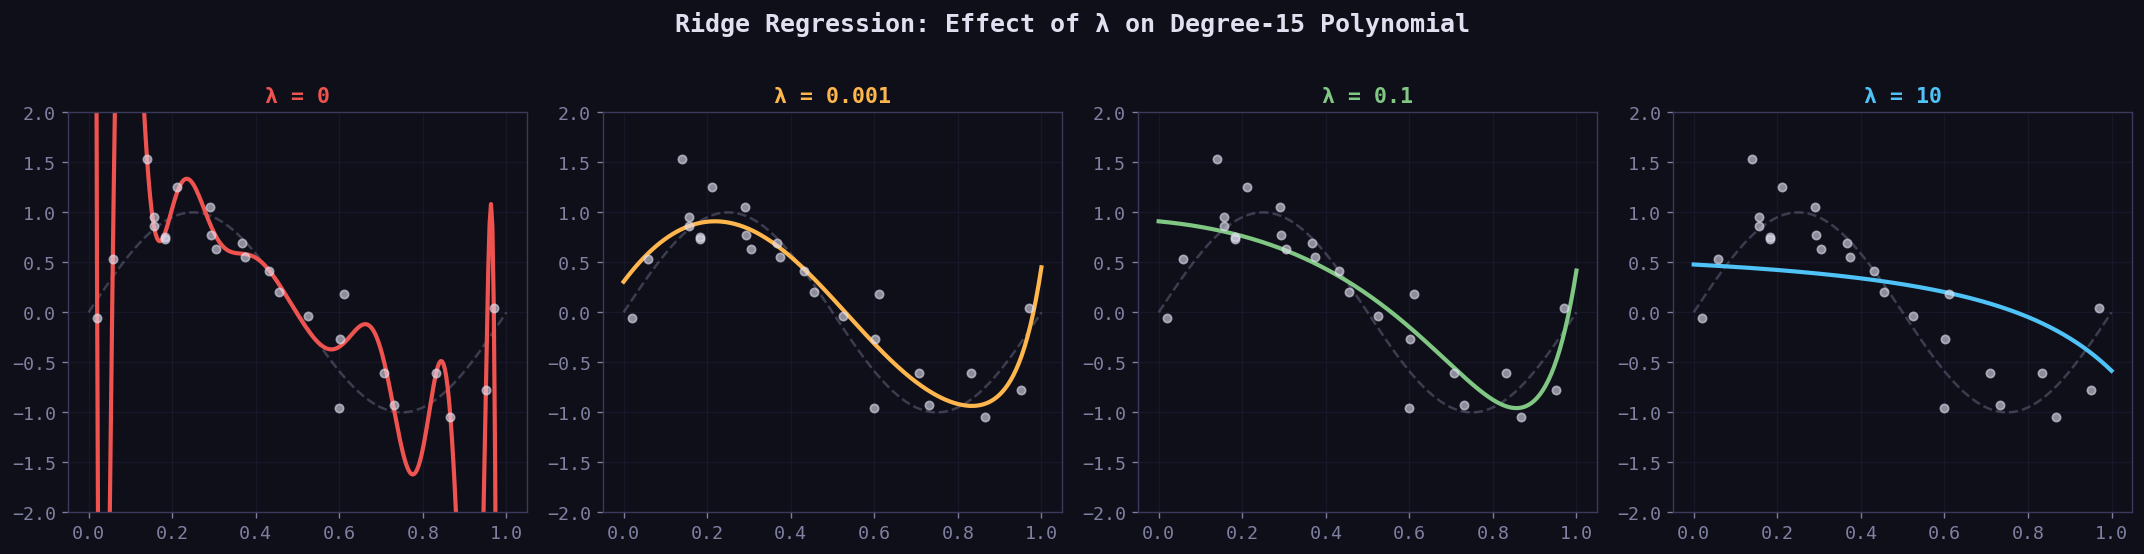

In [4]:
# Ridge in action: taming a high-degree polynomial
np.random.seed(42)
n = 25
X = np.sort(np.random.uniform(0, 1, n))
y_true = np.sin(2 * np.pi * X)
y = y_true + np.random.normal(0, 0.3, n)
X_plot = np.linspace(0, 1, 300)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
alphas = [0, 0.001, 0.1, 10]
colors_list = [C['red'], C['orange'], C['green'], C['blue']]

for ax, alpha, color in zip(axes, alphas, colors_list):
    if alpha == 0:
        model = make_pipeline(PolynomialFeatures(15), LinearRegression())
    else:
        model = make_pipeline(PolynomialFeatures(15), Ridge(alpha=alpha))
    model.fit(X.reshape(-1, 1), y)
    y_pred = model.predict(X_plot.reshape(-1, 1))
    
    ax.scatter(X, y, c=C['white'], s=25, alpha=0.6, zorder=5)
    ax.plot(X_plot, np.sin(2 * np.pi * X_plot), '--', c=C['gray'], alpha=0.4)
    ax.plot(X_plot, y_pred, c=color, lw=2.5)
    ax.set_title(f'λ = {alpha}', fontsize=13, fontweight='bold', color=color)
    ax.set_ylim(-2, 2)

fig.suptitle('Ridge Regression: Effect of λ on Degree-15 Polynomial',
             fontsize=15, fontweight='bold', color=C['white'], y=1.02)
plt.tight_layout()
plt.show()

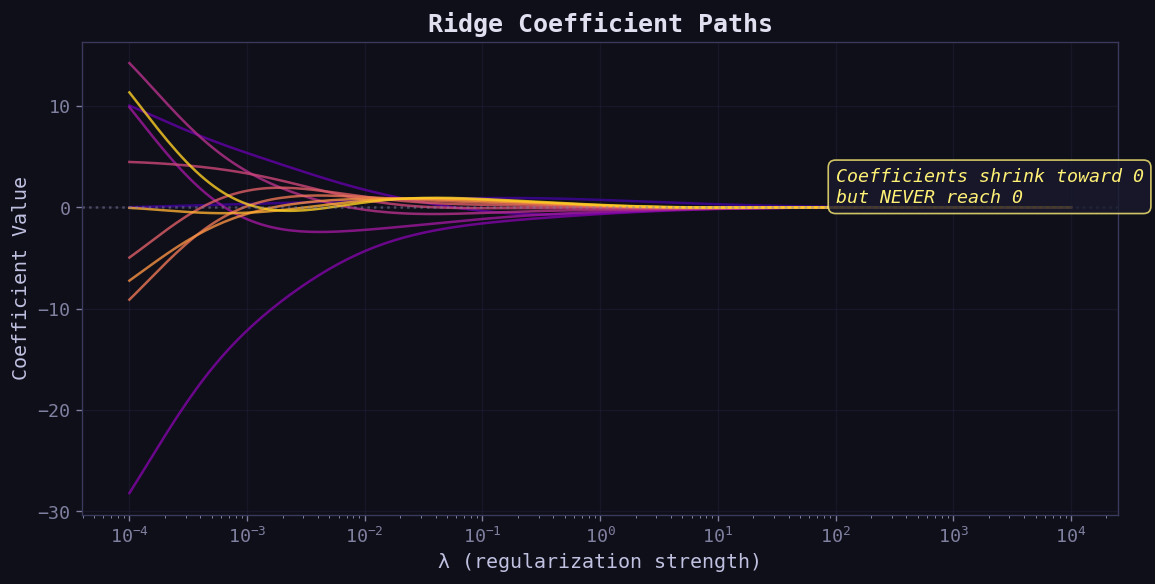

In [5]:
# Ridge coefficient paths — see how weights shrink as λ increases
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(10)
X_poly = poly.fit_transform(X.reshape(-1, 1))

alphas_range = np.logspace(-4, 4, 200)
coefs = []

for a in alphas_range:
    ridge = Ridge(alpha=a, fit_intercept=False)
    ridge.fit(X_poly, y)
    coefs.append(ridge.coef_)

coefs = np.array(coefs)

fig, ax = plt.subplots(figsize=(10, 5))
palette = plt.cm.plasma(np.linspace(0.1, 0.9, coefs.shape[1]))

for i in range(coefs.shape[1]):
    ax.plot(alphas_range, coefs[:, i], c=palette[i], lw=1.5, alpha=0.8)

ax.set_xscale('log')
ax.set_xlabel('λ (regularization strength)', fontsize=12)
ax.set_ylabel('Coefficient Value', fontsize=12)
ax.set_title('Ridge Coefficient Paths', fontsize=15, fontweight='bold', color=C['white'])
ax.axhline(0, c=C['gray'], ls=':', alpha=0.5)
ax.annotate('Coefficients shrink toward 0\nbut NEVER reach 0', xy=(1e2, 0.5),
            fontsize=11, color=C['yellow'], fontstyle='italic',
            bbox=dict(boxstyle='round,pad=0.4', fc='#1a1a2e', ec=C['yellow'], alpha=0.8))
plt.tight_layout()
plt.show()

<a id='4'></a>
## 4. L1 Regularization (Lasso Regression)

### The Math

Lasso uses the **L1 norm** (sum of absolute values):

$$\mathcal{J}_{\text{Lasso}} = \frac{1}{2n}\|\mathbf{y} - \mathbf{X}\mathbf{w}\|_2^2 + \lambda \sum_{j=1}^{p} |w_j| = \frac{1}{2n}\|\mathbf{y} - \mathbf{X}\mathbf{w}\|_2^2 + \lambda \|\mathbf{w}\|_1$$

### No Closed-Form Solution!

The absolute value $|w_j|$ is **not differentiable at 0**. We use the **subgradient**:

$$\frac{\partial |w_j|}{\partial w_j} = \begin{cases} +1 & \text{if } w_j > 0 \\ -1 & \text{if } w_j < 0 \\ [-1, +1] & \text{if } w_j = 0 \end{cases}$$

Solved via **coordinate descent** or **proximal gradient** methods.

### Key Properties
- **Drives weights exactly to zero** → automatic **feature selection**
- Produces **sparse** models
- Among correlated features, tends to pick one and zero out the rest
- Cannot select more features than samples ($p > n$ limitation)

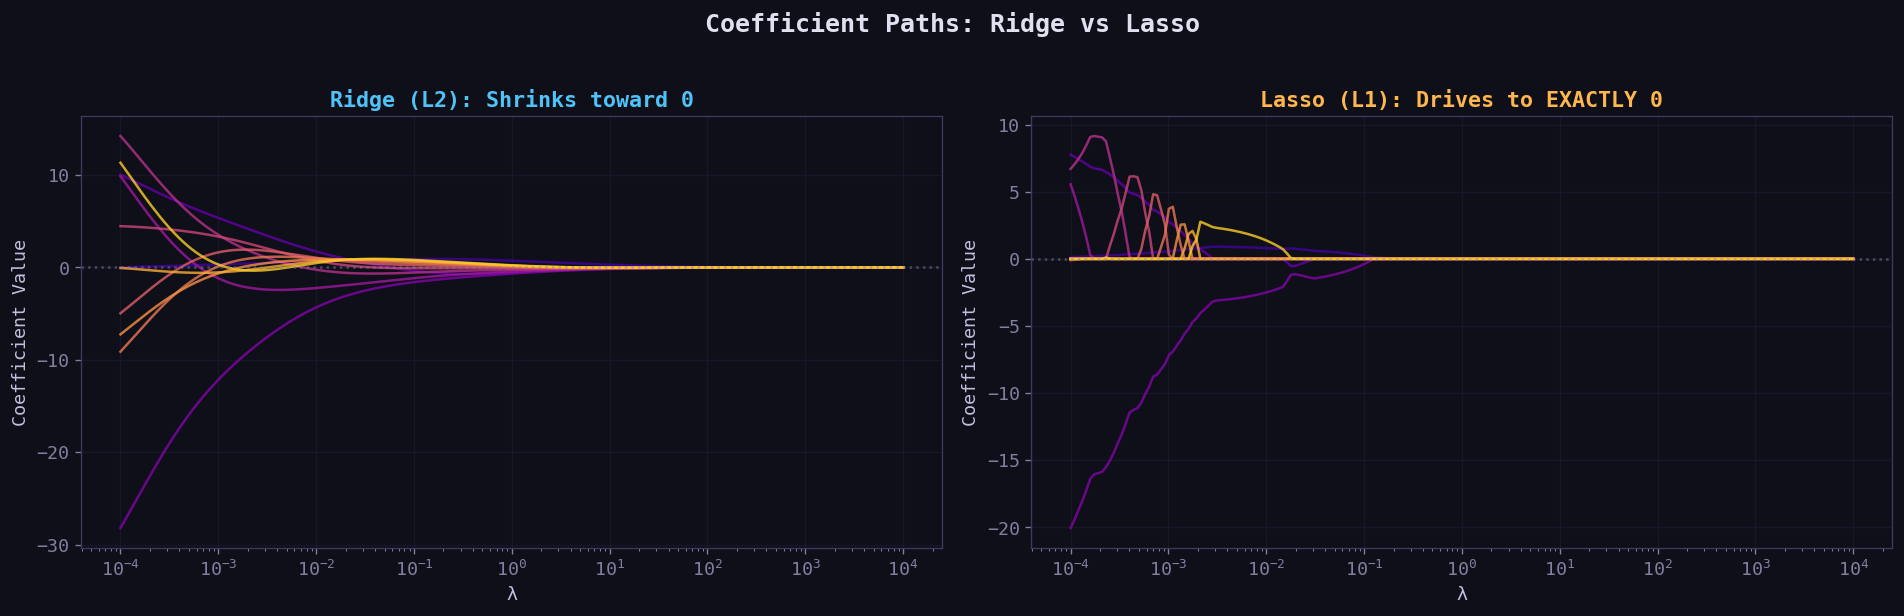

In [6]:
# Lasso coefficient paths — see how weights go to EXACTLY zero
coefs_lasso = []

for a in alphas_range:
    lasso = Lasso(alpha=a, fit_intercept=False, max_iter=10000)
    lasso.fit(X_poly, y)
    coefs_lasso.append(lasso.coef_)

coefs_lasso = np.array(coefs_lasso)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Ridge paths
for i in range(coefs.shape[1]):
    axes[0].plot(alphas_range, coefs[:, i], c=palette[i], lw=1.5, alpha=0.8)
axes[0].set_xscale('log')
axes[0].set_xlabel('λ')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('Ridge (L2): Shrinks toward 0', fontsize=13, fontweight='bold', color=C['blue'])
axes[0].axhline(0, c=C['gray'], ls=':', alpha=0.5)

# Lasso paths
for i in range(coefs_lasso.shape[1]):
    axes[1].plot(alphas_range, coefs_lasso[:, i], c=palette[i], lw=1.5, alpha=0.8)
axes[1].set_xscale('log')
axes[1].set_xlabel('λ')
axes[1].set_ylabel('Coefficient Value')
axes[1].set_title('Lasso (L1): Drives to EXACTLY 0', fontsize=13, fontweight='bold', color=C['orange'])
axes[1].axhline(0, c=C['gray'], ls=':', alpha=0.5)

fig.suptitle('Coefficient Paths: Ridge vs Lasso', fontsize=15, fontweight='bold', color=C['white'], y=1.02)
plt.tight_layout()
plt.show()

<a id='5'></a>
## 5. L1 vs L2: The Geometric Intuition

This is the **most important interview visualization**. Why does L1 produce sparsity but L2 doesn't?

### Constrained Optimization View

The regularized problem is equivalent to:

$$\min_\mathbf{w} \; \mathcal{L}(\mathbf{w}) \quad \text{subject to} \quad \|\mathbf{w}\|_p \leq t$$

- **L1 constraint**: $|w_1| + |w_2| \leq t$ → **Diamond** shape
- **L2 constraint**: $w_1^2 + w_2^2 \leq t$ → **Circle** shape

The **loss contours** (ellipses) expand outward from the unconstrained optimum. The solution is where they **first touch** the constraint region.

- A **diamond** has **corners on the axes** → likely to touch at a corner → **sparse** (some $w_j = 0$)
- A **circle** is **smooth everywhere** → touches at arbitrary points → **non-sparse**

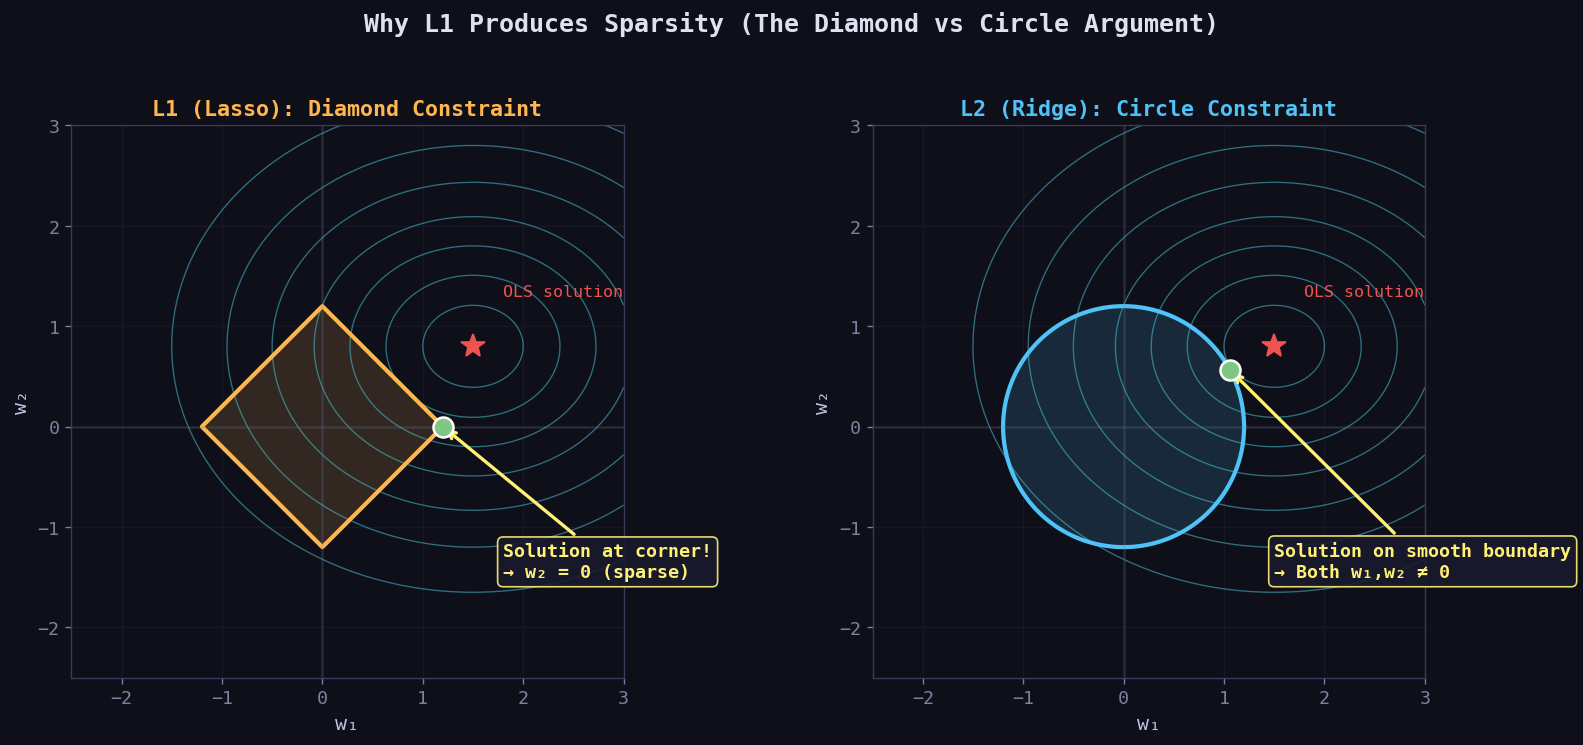

In [7]:
# THE key geometric visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Loss function contours (ellipses centered at unconstrained optimum)
w1_opt, w2_opt = 1.5, 0.8  # unconstrained optimum
w1 = np.linspace(-2.5, 3, 400)
w2 = np.linspace(-2.5, 3, 400)
W1, W2 = np.meshgrid(w1, w2)

# Quadratic loss contours
Loss = 2 * (W1 - w1_opt)**2 + 3 * (W2 - w2_opt)**2
levels = [0.5, 1.5, 3, 5, 8, 12, 18]

titles = ['L1 (Lasso): Diamond Constraint', 'L2 (Ridge): Circle Constraint']
colors_title = [C['orange'], C['blue']]

for idx, ax in enumerate(axes):
    # Draw loss contours
    cs = ax.contour(W1, W2, Loss, levels=levels, colors=[C['cyan']], linewidths=0.8, alpha=0.5)
    
    # Draw constraint region
    t = 1.2  # constraint budget
    theta = np.linspace(0, 2 * np.pi, 500)
    
    if idx == 0:  # L1 diamond
        diamond_w1 = t * np.array([1, 0, -1, 0, 1])
        diamond_w2 = t * np.array([0, 1, 0, -1, 0])
        ax.fill(diamond_w1, diamond_w2, alpha=0.15, color=C['orange'])
        ax.plot(diamond_w1, diamond_w2, c=C['orange'], lw=2.5)
        # Solution at corner
        sol_w1, sol_w2 = t, 0
        ax.annotate('Solution at corner!\n→ w₂ = 0 (sparse)', xy=(sol_w1, sol_w2),
                    xytext=(1.8, -1.5), fontsize=11, color=C['yellow'], fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=C['yellow'], lw=2),
                    bbox=dict(boxstyle='round,pad=0.3', fc='#1a1a2e', ec=C['yellow'], alpha=0.9))
    else:  # L2 circle
        circle_w1 = t * np.cos(theta)
        circle_w2 = t * np.sin(theta)
        ax.fill(circle_w1, circle_w2, alpha=0.15, color=C['blue'])
        ax.plot(circle_w1, circle_w2, c=C['blue'], lw=2.5)
        # Solution on smooth boundary
        angle = np.arctan2(w2_opt, w1_opt)
        sol_w1, sol_w2 = t * np.cos(angle), t * np.sin(angle)
        ax.annotate('Solution on smooth boundary\n→ Both w₁,w₂ ≠ 0', xy=(sol_w1, sol_w2),
                    xytext=(1.5, -1.5), fontsize=11, color=C['yellow'], fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=C['yellow'], lw=2),
                    bbox=dict(boxstyle='round,pad=0.3', fc='#1a1a2e', ec=C['yellow'], alpha=0.9))
    
    # Mark unconstrained optimum
    ax.plot(w1_opt, w2_opt, '*', c=C['red'], markersize=15, zorder=10)
    ax.annotate('OLS solution', xy=(w1_opt, w2_opt), xytext=(w1_opt + 0.3, w2_opt + 0.5),
                fontsize=10, color=C['red'])
    
    # Mark regularized solution
    ax.plot(sol_w1, sol_w2, 'o', c=C['green'], markersize=12, zorder=10, markeredgecolor='white', markeredgewidth=1.5)
    
    ax.set_xlabel('w₁', fontsize=12)
    ax.set_ylabel('w₂', fontsize=12)
    ax.set_title(titles[idx], fontsize=13, fontweight='bold', color=colors_title[idx])
    ax.set_xlim(-2.5, 3)
    ax.set_ylim(-2.5, 3)
    ax.axhline(0, c=C['gray'], ls='-', alpha=0.2)
    ax.axvline(0, c=C['gray'], ls='-', alpha=0.2)
    ax.set_aspect('equal')

fig.suptitle('Why L1 Produces Sparsity (The Diamond vs Circle Argument)',
             fontsize=15, fontweight='bold', color=C['white'], y=1.03)
plt.tight_layout()
plt.show()

### Summary Table: L1 vs L2

| Property | L1 (Lasso) | L2 (Ridge) |
|----------|-----------|------------|
| Penalty | $\lambda\sum|w_j|$ | $\lambda\sum w_j^2$ |
| Geometry | Diamond | Circle |
| Sparsity | ✅ Yes (feature selection) | ❌ No (shrinks all) |
| Closed form | ❌ No | ✅ Yes |
| Correlated features | Picks one arbitrarily | Distributes weight |
| Differentiable | ❌ Not at $w_j=0$ | ✅ Yes, everywhere |
| Use when | Many irrelevant features | All features matter |

<a id='6'></a>
## 6. Elastic Net (L1 + L2 Combined)

### The Math

Elastic Net combines **both** penalties:

$$\mathcal{J}_{\text{ElasticNet}} = \frac{1}{2n}\|\mathbf{y} - \mathbf{X}\mathbf{w}\|_2^2 + \lambda_1 \|\mathbf{w}\|_1 + \lambda_2 \|\mathbf{w}\|_2^2$$

Or equivalently with a **mixing ratio** $\rho \in [0, 1]$:

$$\mathcal{J} = \frac{1}{2n}\|\mathbf{y} - \mathbf{X}\mathbf{w}\|_2^2 + \lambda \left[ \rho \|\mathbf{w}\|_1 + \frac{(1-\rho)}{2} \|\mathbf{w}\|_2^2 \right]$$

### Why Elastic Net?

- **$\rho = 1$**: Pure Lasso
- **$\rho = 0$**: Pure Ridge
- **$0 < \rho < 1$**: Best of both worlds!

Elastic Net fixes Lasso's problems:
1. Can select **more than $n$ features** (Lasso can't)
2. With correlated features, selects **groups** instead of just one

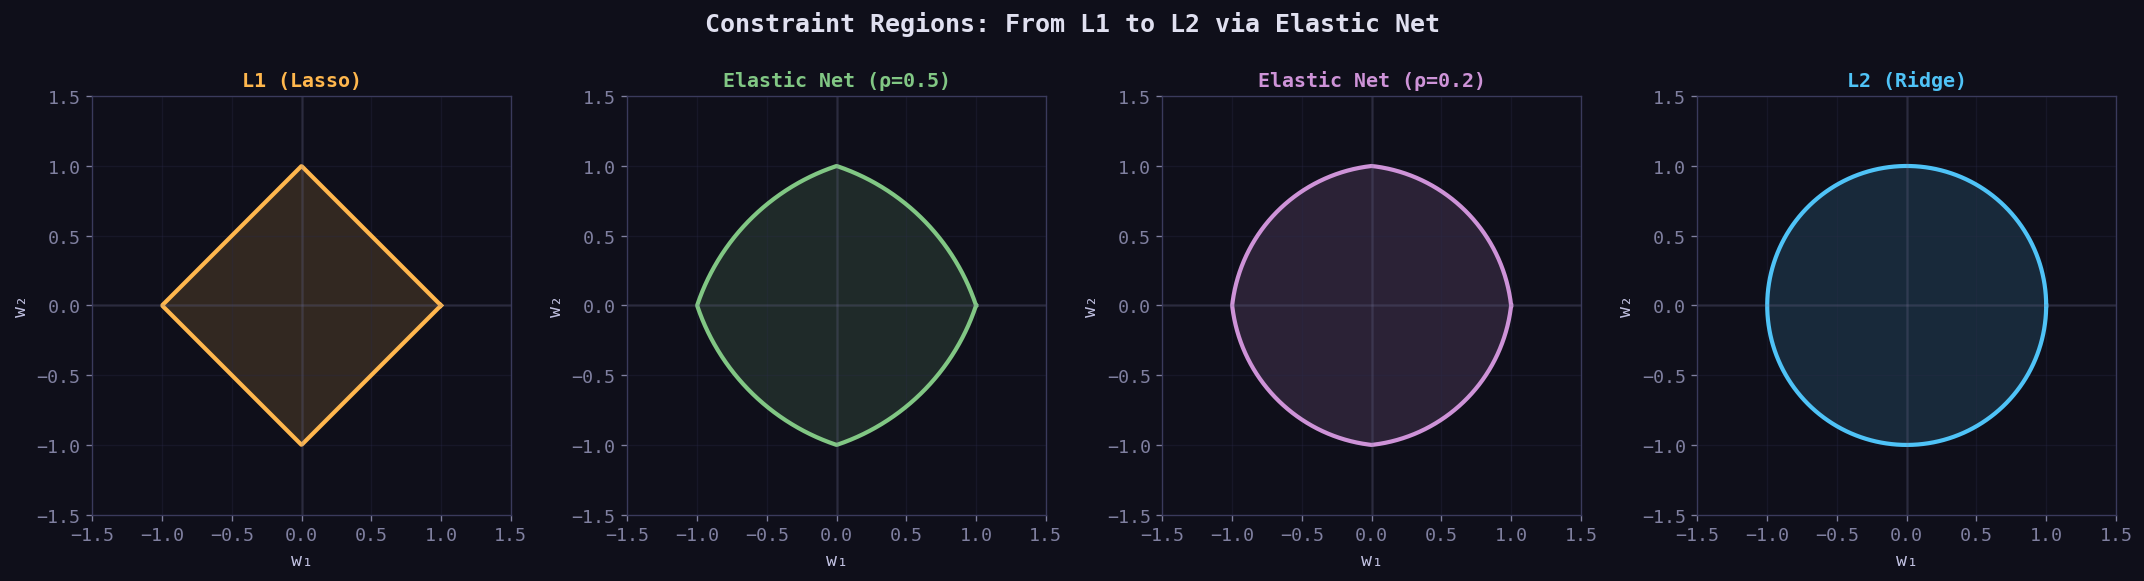

In [8]:
# Visualize the constraint regions for different Lp norms
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

theta = np.linspace(0, 2 * np.pi, 1000)
configs = [
    ('L1 (Lasso)', 1.0, C['orange']),
    ('Elastic Net (ρ=0.5)', 0.5, C['green']),
    ('Elastic Net (ρ=0.2)', 0.2, C['purple']),
    ('L2 (Ridge)', 0.0, C['blue']),
]

for ax, (title, rho, color) in zip(axes, configs):
    # For visualization, we show the unit ball of the combined norm
    # |w1|^p + |w2|^p = 1 for different effective p
    # Elastic net constraint is rho*|w| + (1-rho)*w^2 <= 1
    
    points_w1 = []
    points_w2 = []
    
    for t in np.linspace(0, 2 * np.pi, 1000):
        w1_dir = np.cos(t)
        w2_dir = np.sin(t)
        
        # Find r such that rho*(|r*w1| + |r*w2|) + (1-rho)*(r^2*w1^2 + r^2*w2^2) = 1
        a_coef = (1 - rho) * (w1_dir**2 + w2_dir**2)
        b_coef = rho * (abs(w1_dir) + abs(w2_dir))
        
        if a_coef == 0:
            r = 1.0 / b_coef if b_coef > 0 else 1.0
        else:
            r = (-b_coef + np.sqrt(b_coef**2 + 4 * a_coef)) / (2 * a_coef)
        
        points_w1.append(r * w1_dir)
        points_w2.append(r * w2_dir)
    
    ax.fill(points_w1, points_w2, alpha=0.15, color=color)
    ax.plot(points_w1, points_w2, c=color, lw=2.5)
    ax.set_title(title, fontsize=12, fontweight='bold', color=color)
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.axhline(0, c=C['gray'], ls='-', alpha=0.2)
    ax.axvline(0, c=C['gray'], ls='-', alpha=0.2)
    ax.set_xlabel('w₁')
    ax.set_ylabel('w₂')

fig.suptitle('Constraint Regions: From L1 to L2 via Elastic Net',
             fontsize=15, fontweight='bold', color=C['white'], y=1.03)
plt.tight_layout()
plt.show()

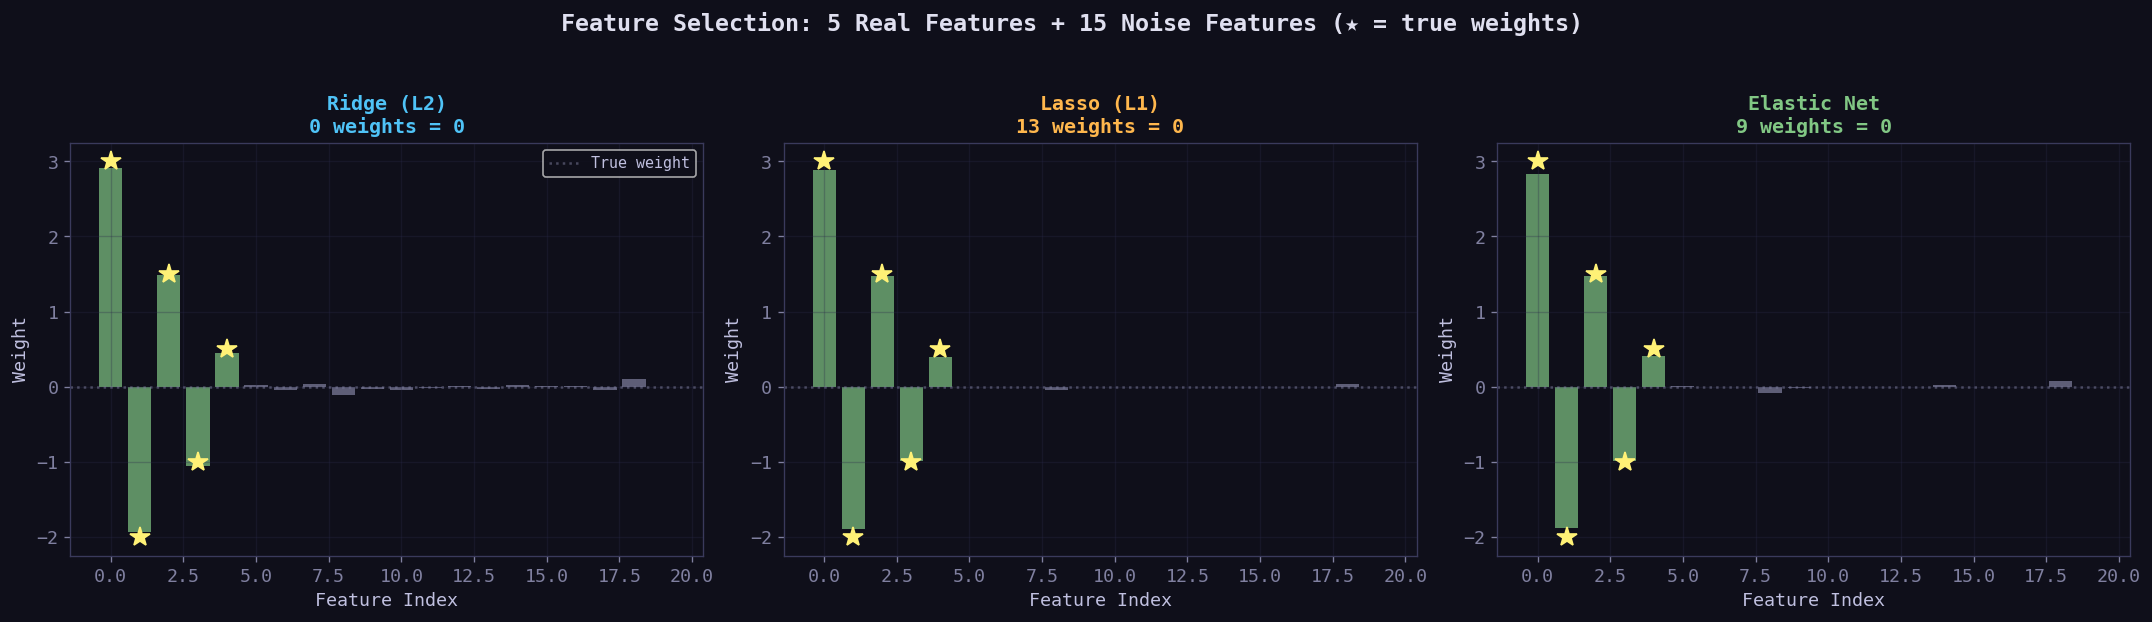

In [9]:
# Practical comparison on a feature selection task
np.random.seed(42)
n_samples, n_features = 100, 20

# Only 5 features are truly relevant
X_data = np.random.randn(n_samples, n_features)
true_weights = np.zeros(n_features)
true_weights[:5] = [3, -2, 1.5, -1, 0.5]  # first 5 are relevant
y_data = X_data @ true_weights + np.random.normal(0, 0.5, n_samples)

# Fit all three models
alpha = 0.5
models = {
    'Ridge (L2)':      Ridge(alpha=alpha),
    'Lasso (L1)':      Lasso(alpha=alpha / 10, max_iter=10000),
    'Elastic Net':     ElasticNet(alpha=alpha / 10, l1_ratio=0.5, max_iter=10000),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_colors = [C['blue'], C['orange'], C['green']]

for ax, (name, model), color in zip(axes, models.items(), model_colors):
    model.fit(X_data, y_data)
    w = model.coef_
    
    bars = ax.bar(range(n_features), w, color=[C['green'] if i < 5 else C['gray'] for i in range(n_features)],
                  alpha=0.7, edgecolor='none')
    
    # Highlight zero weights
    n_zero = np.sum(np.abs(w) < 1e-6)
    ax.set_title(f'{name}\n{n_zero} weights = 0', fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Feature Index')
    ax.set_ylabel('Weight')
    ax.axhline(0, c=C['gray'], ls=':', alpha=0.5)
    
    # Mark true relevant features
    for i in range(5):
        ax.plot(i, true_weights[i], '*', c=C['yellow'], markersize=12, zorder=10)

axes[0].legend(['True weight'], fontsize=9, loc='upper right')
fig.suptitle('Feature Selection: 5 Real Features + 15 Noise Features (★ = true weights)',
             fontsize=14, fontweight='bold', color=C['white'], y=1.03)
plt.tight_layout()
plt.show()

<a id='7'></a>
## 7. Regularization in Neural Networks

Deep learning uses additional regularization techniques beyond L1/L2.

---

### 7.1 Weight Decay

Weight decay in SGD directly shrinks weights each step:

$$\mathbf{w}_{t+1} = (1 - \eta \lambda) \, \mathbf{w}_t - \eta \, \nabla_\mathbf{w} \mathcal{L}$$

- For vanilla SGD, **weight decay = L2 regularization**
- For Adam/AdaGrad, they differ! → Use **decoupled weight decay** (AdamW)

### 7.2 Dropout

During training, randomly set each neuron's output to 0 with probability $p$:

$$\tilde{h}_i = \begin{cases} 0 & \text{with probability } p \\ \frac{h_i}{1-p} & \text{with probability } 1-p \end{cases}$$

The $\frac{1}{1-p}$ scaling ensures expected values match at test time (**inverted dropout**).

**Why it works:**
- Forces redundant representations (can't rely on any single neuron)
- Equivalent to training an **ensemble** of $2^n$ thinned networks
- Acts as approximate Bayesian inference

### 7.3 Batch Normalization

Normalize activations within each mini-batch:

$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$
$$y_i = \gamma \hat{x}_i + \beta$$

Has a **regularization side-effect** because mini-batch statistics add noise.

### 7.4 Early Stopping

Stop training when **validation loss** starts increasing.

**Mathematically**: Limiting training iterations is equivalent to constraining the effective capacity of the model. For quadratic loss, early stopping with gradient descent is equivalent to L2 regularization with $\lambda \propto \frac{1}{\tau}$ where $\tau$ is the number of steps.

### 7.5 Data Augmentation

Create transformed copies of training data (flips, rotations, crops, noise injection).

This effectively **increases the training set** and encodes **invariance priors** into the model.

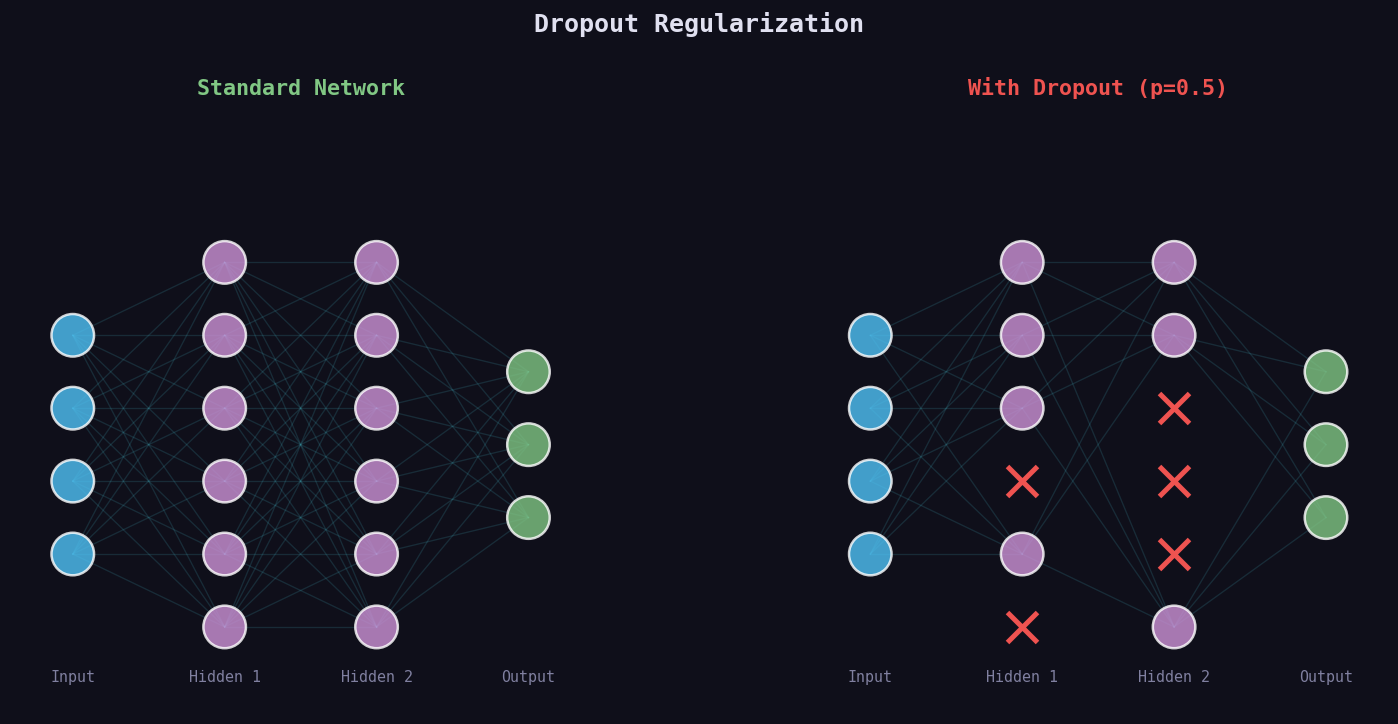

In [10]:
# Visualize Dropout
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

np.random.seed(7)

for ax_idx, (ax, title, dropout) in enumerate(zip(axes, ['Standard Network', 'With Dropout (p=0.5)'], [False, True])):
    layers = [4, 6, 6, 3]
    positions = []
    
    for l, n_neurons in enumerate(layers):
        x_pos = l * 2.5
        layer_pos = []
        for j in range(n_neurons):
            y_pos = (j - n_neurons / 2) * 1.2
            layer_pos.append((x_pos, y_pos))
        positions.append(layer_pos)
    
    # Determine which neurons are dropped
    dropped = []
    for l in range(len(layers)):
        if dropout and l > 0 and l < len(layers) - 1:  # don't drop input/output
            mask = np.random.random(layers[l]) < 0.5
            dropped.append(mask)
        else:
            dropped.append(np.zeros(layers[l], dtype=bool))
    
    # Draw connections
    for l in range(len(layers) - 1):
        for i, (x1, y1) in enumerate(positions[l]):
            for j, (x2, y2) in enumerate(positions[l + 1]):
                if dropped[l][i] or dropped[l + 1][j]:
                    continue
                ax.plot([x1, x2], [y1, y2], c=C['cyan'], alpha=0.15, lw=0.8)
    
    # Draw neurons
    for l in range(len(layers)):
        for i, (x, y) in enumerate(positions[l]):
            if dropped[l][i]:
                ax.plot(x, y, 'x', c=C['red'], markersize=18, markeredgewidth=3, zorder=10)
            else:
                circle = plt.Circle((x, y), 0.35, fc=C['blue'] if l == 0 else C['green'] if l == len(layers)-1 else C['purple'],
                                   ec='white', lw=1.5, alpha=0.8, zorder=10)
                ax.add_patch(circle)
    
    ax.set_xlim(-1, 8.5)
    ax.set_ylim(-5, 5)
    ax.set_title(title, fontsize=13, fontweight='bold', 
                 color=C['red'] if dropout else C['green'])
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Layer labels
    for l, name in enumerate(['Input', 'Hidden 1', 'Hidden 2', 'Output']):
        ax.text(l * 2.5, -4.5, name, ha='center', fontsize=9, color=C['gray'])

fig.suptitle('Dropout Regularization', fontsize=15, fontweight='bold', color=C['white'], y=1.0)
plt.tight_layout()
plt.show()

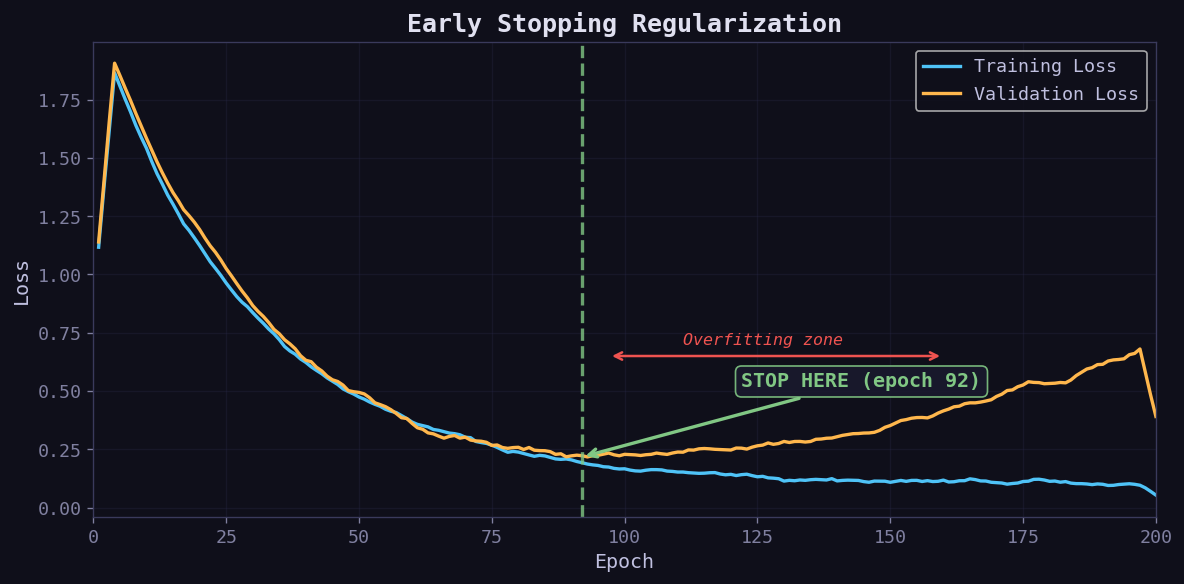

In [11]:
# Fixed Early Stopping visualization (self-contained)
np.random.seed(42)
epochs = 200
t = np.arange(1, epochs + 1)

train_loss = 2.0 * np.exp(-t / 30) + 0.1 + np.random.normal(0, 0.02, epochs)
val_loss = 2.0 * np.exp(-t / 30) + 0.1 + 0.003 * (t - 60)**2 / 100 + np.random.normal(0, 0.03, epochs)
val_loss[:30] = train_loss[:30] + np.random.normal(0.05, 0.02, 30)

def smooth(y, w=5):
    return np.convolve(y, np.ones(w)/w, mode='same')

train_s = smooth(train_loss, 7)
val_s = smooth(val_loss, 7)
best_epoch = np.argmin(val_s[10:]) + 10

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, train_s, c=C['blue'], lw=2, label='Training Loss')
ax.plot(t, val_s, c=C['orange'], lw=2, label='Validation Loss')
ax.axvline(best_epoch, ls='--', c=C['green'], lw=2, alpha=0.8)
ax.annotate(f'STOP HERE (epoch {best_epoch})', xy=(best_epoch, val_s[best_epoch]),
            xytext=(best_epoch + 30, val_s[best_epoch] + 0.3),
            fontsize=12, color=C['green'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=C['green'], lw=2),
            bbox=dict(boxstyle='round,pad=0.3', fc='#1a1a2e', ec=C['green'], alpha=0.9))

ax.annotate('', xy=(160, 0.65), xytext=(best_epoch + 5, 0.65),
            arrowprops=dict(arrowstyle='<->', color=C['red'], lw=1.5))
ax.text((160 + best_epoch) / 2, 0.70, 'Overfitting zone', ha='center',
        fontsize=10, color=C['red'], fontstyle='italic')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Early Stopping Regularization', fontsize=15, fontweight='bold', color=C['white'])
ax.legend(fontsize=11)
ax.set_xlim(0, 200)
plt.tight_layout()
plt.show()

<a id='8'></a>
## 8. Bayesian Interpretation of Regularization

This is an elegant and frequently asked interview topic.

### MAP Estimation

In Bayesian inference, we want the **posterior**:

$$P(\mathbf{w} | \text{data}) \propto \underbrace{P(\text{data} | \mathbf{w})}_{\text{likelihood}} \cdot \underbrace{P(\mathbf{w})}_{\text{prior}}$$

**Maximum A Posteriori (MAP)** estimation:

$$\hat{\mathbf{w}}_{\text{MAP}} = \arg\max_\mathbf{w} \; \log P(\text{data}|\mathbf{w}) + \log P(\mathbf{w})$$

### L2 = Gaussian Prior

If the prior is $w_j \sim \mathcal{N}(0, \tau^2)$:

$$\log P(\mathbf{w}) = -\frac{1}{2\tau^2} \sum_j w_j^2 + \text{const}$$

This is exactly the **L2 penalty** with $\lambda = \frac{\sigma^2}{\tau^2}$ (where $\sigma^2$ is the noise variance).

### L1 = Laplace Prior

If the prior is $w_j \sim \text{Laplace}(0, b)$:

$$P(w_j) = \frac{1}{2b} \exp\left(-\frac{|w_j|}{b}\right)$$

$$\log P(\mathbf{w}) = -\frac{1}{b} \sum_j |w_j| + \text{const}$$

This is exactly the **L1 penalty** with $\lambda = \frac{\sigma^2}{b}$.

### Intuition

The Laplace distribution has a **sharp peak at zero** and heavy tails → encourages sparsity.

The Gaussian is smooth and round → shrinks everything, zeros nothing.

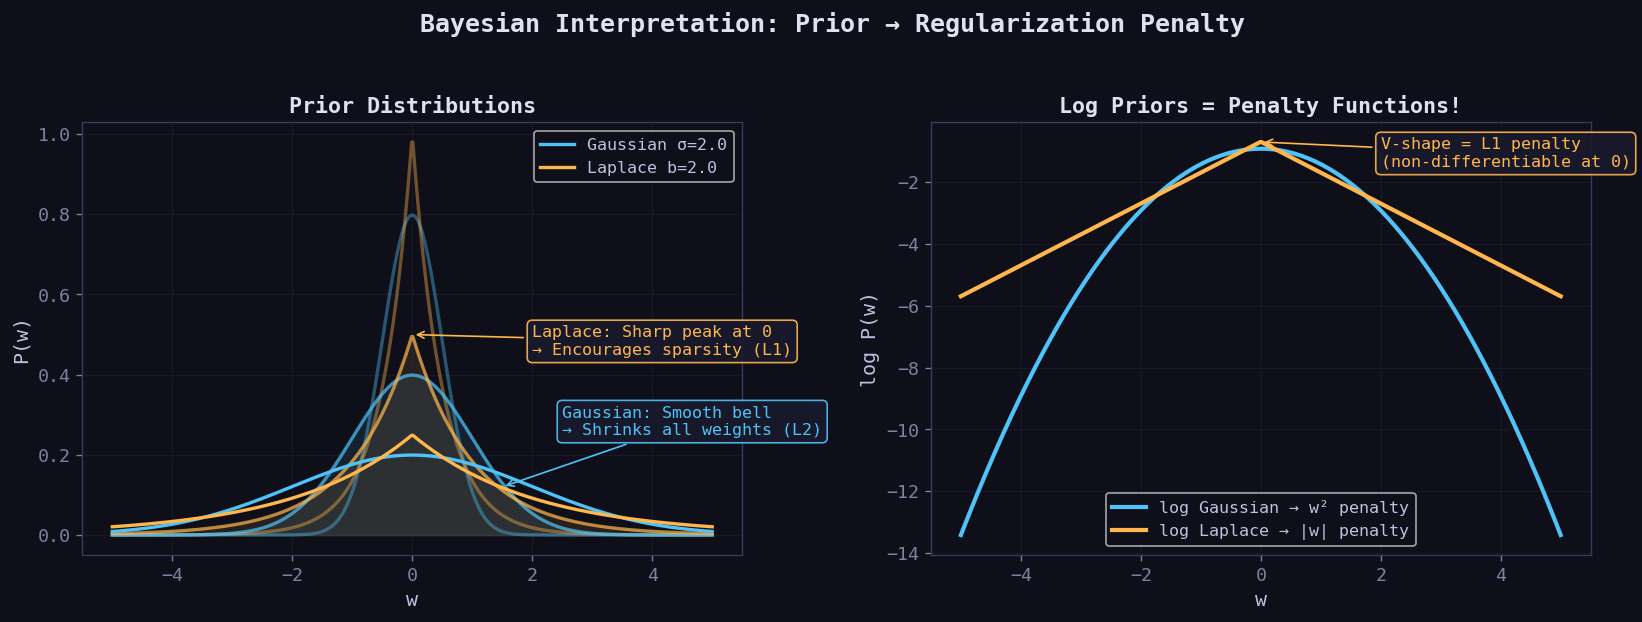

In [12]:
# Bayesian priors visualization
from scipy.stats import norm, laplace

x = np.linspace(-5, 5, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PDF comparison
ax = axes[0]
for scale, alpha_val in [(0.5, 0.4), (1.0, 0.7), (2.0, 1.0)]:
    ax.plot(x, norm.pdf(x, 0, scale), c=C['blue'], lw=2, alpha=alpha_val,
            label=f'Gaussian σ={scale}' if alpha_val == 1.0 else None)
    ax.plot(x, laplace.pdf(x, 0, scale), c=C['orange'], lw=2, alpha=alpha_val,
            label=f'Laplace b={scale}' if alpha_val == 1.0 else None)

ax.fill_between(x, 0, norm.pdf(x, 0, 1), alpha=0.1, color=C['blue'])
ax.fill_between(x, 0, laplace.pdf(x, 0, 1), alpha=0.1, color=C['orange'])

ax.set_title('Prior Distributions', fontsize=13, fontweight='bold', color=C['white'])
ax.set_xlabel('w', fontsize=12)
ax.set_ylabel('P(w)', fontsize=12)
ax.legend(fontsize=10)

ax.annotate('Laplace: Sharp peak at 0\n→ Encourages sparsity (L1)',
            xy=(0, 0.5), xytext=(2, 0.45), fontsize=10, color=C['orange'],
            arrowprops=dict(arrowstyle='->', color=C['orange']),
            bbox=dict(boxstyle='round,pad=0.3', fc='#1a1a2e', ec=C['orange'], alpha=0.9))
ax.annotate('Gaussian: Smooth bell\n→ Shrinks all weights (L2)',
            xy=(1.5, 0.12), xytext=(2.5, 0.25), fontsize=10, color=C['blue'],
            arrowprops=dict(arrowstyle='->', color=C['blue']),
            bbox=dict(boxstyle='round,pad=0.3', fc='#1a1a2e', ec=C['blue'], alpha=0.9))

# Log PDF comparison (shows the key difference more clearly)
ax = axes[1]
ax.plot(x, np.log(norm.pdf(x, 0, 1) + 1e-10), c=C['blue'], lw=2.5, label='log Gaussian → w² penalty')
ax.plot(x, np.log(laplace.pdf(x, 0, 1) + 1e-10), c=C['orange'], lw=2.5, label='log Laplace → |w| penalty')

ax.set_title('Log Priors = Penalty Functions!', fontsize=13, fontweight='bold', color=C['white'])
ax.set_xlabel('w', fontsize=12)
ax.set_ylabel('log P(w)', fontsize=12)
ax.legend(fontsize=10)

ax.annotate('V-shape = L1 penalty\n(non-differentiable at 0)',
            xy=(0, -0.7), xytext=(2, -1.5), fontsize=10, color=C['orange'],
            arrowprops=dict(arrowstyle='->', color=C['orange']),
            bbox=dict(boxstyle='round,pad=0.3', fc='#1a1a2e', ec=C['orange'], alpha=0.9))

fig.suptitle('Bayesian Interpretation: Prior → Regularization Penalty',
             fontsize=15, fontweight='bold', color=C['white'], y=1.03)
plt.tight_layout()
plt.show()

# Regularization — Interview Questions & Answers (Expanded)

*Comprehensive answers with the depth interviewers expect. Each question includes follow-up traps and how to handle them.*

---

## Fundamentals

### Q1: What is regularization and why do we need it?

**A:** Regularization is any technique that constrains a model to prevent overfitting. We modify the loss function by adding a penalty term:

$$\hat{\theta} = \arg\min_{\theta} \; \mathcal{L}(\theta) + \lambda \, \Omega(\theta)$$

The penalty $\Omega(\theta)$ discourages overly complex models. This trades a small increase in bias for a large decrease in variance, reducing generalization error.

**Follow-up trap — "But isn't more complexity always better?"**
No. The bias-variance tradeoff tells us that total error = Bias² + Variance + irreducible noise. A complex model has low bias but high variance (it memorizes training noise). Regularization increases bias slightly but reduces variance significantly, often lowering total error on unseen data.

---

### Q2: What is a weight, and why does regularization target weights?

**A:** A weight is a number that scales how much a specific input feature contributes to the prediction. In a model like:

$$\hat{y} = w_1 \cdot \text{sqft} + w_2 \cdot \text{bedrooms} + b$$

$w_1 = 150$ means "each extra square foot adds \$150 to the price." When a weight is zero, that feature is multiplied by zero and effectively deleted from the model.

Regularization targets weights because large weights mean the model is relying heavily on certain features, making it sensitive to small input changes — a hallmark of overfitting. By penalizing large weights, we force the model to be more conservative.

**Follow-up trap — "Do we penalize the bias term?"**
No. The bias $b$ just shifts predictions up or down globally. It doesn't amplify input sensitivity, so it doesn't contribute to overfitting.

---

## L1 vs L2

### Q3: Explain the difference between L1 and L2 regularization.

**A:** Both add a penalty to the loss, but the penalty shape differs:

- **L2 (Ridge)** adds $\lambda \sum w_j^2$ — the sum of *squared* weights
- **L1 (Lasso)** adds $\lambda \sum |w_j|$ — the sum of *absolute* weights

The critical difference: L2 shrinks all weights toward zero but never exactly to zero. L1 drives some weights to *exactly* zero, performing automatic feature selection.

**Follow-up trap — "Can you write out the full loss with L2 for, say, 3 features?"**

$$\mathcal{J} = \frac{1}{n}\sum_{i=1}^{n}(y_i - w_1 x_{i1} - w_2 x_{i2} - w_3 x_{i3} - b)^2 + \lambda(w_1^2 + w_2^2 + w_3^2)$$

---

### Q4: Why does L1 produce sparse solutions but L2 doesn't?

**A:** Three perspectives, from most intuitive to most rigorous:

**1. Tug-of-war (intuitive):** Every weight has two forces on it — the data pulling it to whatever value reduces error, and regularization pushing it toward zero. For useless features, data exerts no pull, so regularization wins. L1's push is a constant $\lambda$ regardless of weight size, so it marches straight to zero. L2's push is $2\lambda w_j$ — it weakens as the weight shrinks, so it asymptotically approaches zero but never arrives.

**2. Gradient (mathematical):** The L1 penalty gradient is $\pm\lambda$ (constant), while the L2 penalty gradient is $2\lambda w_j$ (proportional to the weight). When $w_j = 0.001$, L2's push is $2\lambda \times 0.001$ — negligible. L1 still pushes with full force $\lambda$.

**3. Geometric (visual):** The L1 constraint region $|w_1| + |w_2| \leq t$ is a diamond. The L2 constraint $w_1^2 + w_2^2 \leq t$ is a circle. Loss contours (ellipses) expanding from the optimum tend to touch the diamond at a corner (where at least one weight = 0), because corners are pointy and stick out. The circle is smooth everywhere, so the touching point is generically at a non-axis location where both weights are non-zero.

**Follow-up trap — "Does L1 *always* give exact zeros?"**
Not necessarily. If the data pull for every feature is very strong (all features genuinely useful) and $\lambda$ is small, no weights may reach zero. Sparsity depends on both the data and the choice of $\lambda$.

---

### Q5: You mentioned the geometric intuition — what exactly is that diamond/circle picture?

**A:** The regularized optimization can be rewritten as a constrained problem:

$$\min_\mathbf{w} \mathcal{L}(\mathbf{w}) \quad \text{subject to} \quad \|\mathbf{w}\|_p \leq t$$

For two weights $w_1, w_2$:
- L1 constraint: $|w_1| + |w_2| \leq t$ → a **diamond** shape
- L2 constraint: $w_1^2 + w_2^2 \leq t$ → a **circle**

The loss function creates elliptical contour lines expanding outward from the unconstrained optimum. The regularized solution is where the smallest contour first touches the constraint boundary.

A diamond has **corners on the axes** — those are points where one weight equals zero. Because corners are pointy protrusions, ellipses are geometrically likely to make first contact there. A circle has no corners, so the contact point is almost never on an axis.

**Why this matters:** Corner = one weight is on the axis = that weight is zero = the corresponding feature is removed from the model. That's feature selection from geometry.

---

### Q6: How does regularization "know" which features are useless?

**A:** It doesn't. Regularization is completely blind — it applies the same penalty to every weight equally. Think of it as a uniform tax on all weights.

The "knowing" comes from the data. For useful features, the data gradient is strong — it pulls the weight away from zero, overcoming the tax. For useless features, the data gradient is near zero — there's no pull to resist the tax, so regularization pushes the weight to zero unopposed.

So regularization creates a cost for existing. Features that earn their keep (by reducing loss) can afford the cost. Features that don't contribute can't justify it.

---

## Gradients and Optimization

### Q7: What does the gradient look like after taking the derivative with L2?

**A:** For weight $w_j$:

$$\frac{\partial \mathcal{J}}{\partial w_j} = \underbrace{-\frac{2}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)x_{ij}}_{\text{data signal}} + \underbrace{2\lambda w_j}_{\text{L2 penalty}}$$

The first term tells the weight where to go to reduce prediction error. The second term pushes it toward zero. Each step, the weight moves based on whoever pulls harder.

**Follow-up — "What about L1?"**

$$\frac{\partial \mathcal{J}}{\partial w_j} = -\frac{2}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)x_{ij} + \lambda \cdot \text{sign}(w_j)$$

The penalty gradient is $\pm\lambda$ — a constant, not dependent on $w_j$.

---

### Q8: If I have 3 weights, do I get 3 gradients?

**A:** Yes. Each weight gets its own partial derivative, and all update simultaneously:

$$w_j \leftarrow w_j - \eta \cdot \frac{\partial \mathcal{J}}{\partial w_j} \quad \text{for } j = 1, 2, 3$$

But there is still only **one loss function** — it's a single number that depends on all weights together. Each gradient answers: "if I nudge *this specific weight*, does the *overall* loss go up or down?" All nudges happen at once, and the combined effect reduces the single loss.

In vector notation: $\mathbf{w} \leftarrow \mathbf{w} - \eta \nabla_\mathbf{w}\mathcal{J}$, where $\nabla_\mathbf{w}\mathcal{J}$ is the vector of all partial derivatives.

---

## Elastic Net

### Q9: When would you use Elastic Net over pure Lasso or Ridge?

**A:** Elastic Net combines both penalties:

$$\mathcal{J} = \mathcal{L}(\mathbf{w}) + \lambda\left[\rho\|\mathbf{w}\|_1 + \frac{(1-\rho)}{2}\|\mathbf{w}\|_2^2\right]$$

Use it when:
1. **Correlated feature groups** — Lasso picks one arbitrarily from a correlated group. Elastic Net selects them together.
2. **More features than samples** ($p > n$) — Lasso can select at most $n$ features. Elastic Net has no such limit.
3. **You're unsure** — with $\rho = 0.5$ it's a safe default that gives you some feature selection and some stability.

**Follow-up trap — "What is $\rho$?"**
The mixing ratio. $\rho = 1$ is pure Lasso, $\rho = 0$ is pure Ridge, anything in between blends the two penalties. This is a second hyperparameter you tune via cross-validation alongside $\lambda$.

---

## Neural Network Regularization

### Q10: How does dropout work? Why is it effective?

**A:** During training, each neuron's output is randomly set to zero with probability $p$, and surviving outputs are scaled by $\frac{1}{1-p}$ (inverted dropout):

$$\tilde{h}_i = \begin{cases} 0 & \text{with probability } p \\ \frac{h_i}{1-p} & \text{with probability } 1-p \end{cases}$$

Why it works (three explanations):
1. **Prevents co-adaptation** — neurons can't rely on specific other neurons always being present
2. **Implicit ensemble** — equivalent to training $2^n$ different sub-networks and averaging their predictions
3. **Approximate Bayesian inference** — samples from the posterior over network architectures

**Follow-up trap — "Can you use dropout at test time?"**
Standard practice: turn it off (use all neurons). But keeping it on and running multiple forward passes gives **MC Dropout** — the variance across passes estimates model uncertainty. Useful for safety-critical applications.

---

### Q11: Is weight decay the same as L2 regularization?

**A:** For vanilla SGD, **yes**. The update rule:

$$w \leftarrow (1 - \eta\lambda)w - \eta \nabla \mathcal{L}$$

is mathematically identical whether you derive it from L2 penalty or weight decay.

For adaptive optimizers (Adam, RMSProp), **no**. Adam divides the gradient by a running average of squared gradients. If you put L2 into the loss, the penalty gradient also gets divided — the effective regularization varies per parameter. **AdamW** fixes this by applying weight decay *after* the Adam step, decoupled from the gradient. This is why AdamW is preferred in modern deep learning.

**Follow-up trap — "So should I always use AdamW?"**
For neural networks, yes — it's the current standard. For linear models (Ridge/Lasso), you use closed-form solutions or coordinate descent, not SGD, so this distinction doesn't apply.

---

### Q12: Does batch normalization act as regularization?

**A:** Yes, as a side effect. The mini-batch statistics ($\mu_B, \sigma_B^2$) are noisy estimates of the true population statistics. This noise perturbs the activations each step, acting similarly to adding Gaussian noise — a known regularization technique. The effect is stronger with smaller batch sizes.

**Practical implication:** When using BatchNorm, you often don't need dropout (or can use a smaller dropout rate). Using both can sometimes be counterproductive.

---

### Q13: How is early stopping related to regularization?

**A:** Early stopping halts training when validation loss starts increasing. Mathematically, limiting the number of gradient descent steps constrains the effective model complexity.

For linear models: stopping after $\tau$ steps is equivalent to L2 regularization with $\lambda \propto \frac{1}{\tau}$. Fewer steps = stronger regularization.

**Intuition:** Early iterations learn large-scale, genuine patterns (low-frequency components). Later iterations start fitting noise (high-frequency components). Stopping early cuts off the noise-fitting phase.

**Follow-up trap — "Is early stopping free regularization?"**
Almost. It requires a validation set (which reduces training data), and you need to choose a patience hyperparameter. But it adds zero computational overhead to the training process itself.

---

### Q14: What about data augmentation as regularization?

**A:** Data augmentation creates transformed copies of training data (flips, rotations, crops, color jitter, noise injection). This is regularization because it:

1. Effectively increases the training set size
2. Encodes **invariance priors** — telling the model "a flipped cat is still a cat"
3. Reduces overfitting to specific training examples

It's one of the most powerful regularization techniques in computer vision and increasingly in NLP (via techniques like back-translation, synonym replacement).

---

## Bayesian Interpretation

### Q15: What is the Bayesian interpretation of regularization?

**A:** Regularization is equivalent to **Maximum A Posteriori (MAP)** estimation with a prior on weights.

From Bayes' theorem: $P(\mathbf{w}|\text{data}) \propto P(\text{data}|\mathbf{w}) \cdot P(\mathbf{w})$

Taking the log and maximizing:

$$\hat{\mathbf{w}}_{\text{MAP}} = \arg\max_\mathbf{w} \; \underbrace{\log P(\text{data}|\mathbf{w})}_{\text{= negative loss}} + \underbrace{\log P(\mathbf{w})}_{\text{= negative penalty}}$$

- **Gaussian prior** $w_j \sim \mathcal{N}(0, \tau^2)$ → $\log P(\mathbf{w}) = -\frac{1}{2\tau^2}\sum w_j^2 + \text{const}$ → **L2 penalty**
- **Laplace prior** $w_j \sim \text{Laplace}(0, b)$ → $\log P(\mathbf{w}) = -\frac{1}{b}\sum |w_j| + \text{const}$ → **L1 penalty**

The Laplace distribution has a sharp peak at zero (encouraging sparsity). The Gaussian is smooth and round (shrinking everything equally). The regularization strength $\lambda$ corresponds to how tight the prior is — a narrow prior (small $\tau$ or $b$) means strong regularization.

**Follow-up trap — "What's the difference between MAP and MLE?"**
Maximum Likelihood Estimation (MLE) has no prior — it only maximizes $P(\text{data}|\mathbf{w})$, which is equivalent to no regularization ($\lambda = 0$). MAP adds the prior, which is the penalty term.

---

## Practical Decisions

### Q16: How do you choose the regularization hyperparameter $\lambda$?

**A:** **Cross-validation** is the standard approach:

1. Define a grid of $\lambda$ values (logarithmic: $10^{-4}, 10^{-3}, \ldots, 10^{4}$)
2. For each $\lambda$, run $k$-fold CV (typically $k = 5$)
3. For each fold: train on $k-1$ folds, evaluate on the held-out fold
4. Average the error across all folds for each $\lambda$
5. Pick the $\lambda$ with the lowest average error
6. Retrain on all data with that $\lambda$

Scikit-learn automates this: `RidgeCV`, `LassoCV`, `ElasticNetCV` do everything in one line.

**Follow-up trap — "Why logarithmic grid?"**
Because the effect of $\lambda$ is multiplicative, not additive. The difference between $\lambda = 0.01$ and $\lambda = 0.02$ is tiny compared to $\lambda = 1$ vs $\lambda = 10$. A logarithmic grid covers the relevant range efficiently.

---

### Q17: When should I use which regularization method?

**A:** Decision framework:

| Situation | Use | Why |
|-----------|-----|-----|
| Many irrelevant features, need feature selection | L1 (Lasso) | Drives useless weights to zero |
| Correlated features, want to keep all | L2 (Ridge) | Distributes weight across correlated features |
| Correlated features + feature selection needed | Elastic Net | Best of both worlds |
| Deep neural network | Dropout + AdamW + Early Stopping | Standard modern recipe |
| More features than samples ($p > n$) | Elastic Net or Ridge | Lasso limited to selecting at most $n$ |
| Not sure | Elastic Net ($\rho = 0.5$) | Safe general default |

---

### Q18: What happens if $\lambda$ is too large?

**A:** The model **underfits**. With $\lambda \to \infty$:
- L2 pushes all weights toward zero → model predicts approximately the mean of $y$
- L1 sets all weights to exactly zero → model predicts exactly the mean of $y$

You've traded all variance for maximum bias. The model is too simple to capture any real patterns.

**Follow-up trap — "What if $\lambda$ is too small?"**
Then regularization has no effect, and you're back to ordinary least squares (or unregularized training), which may overfit. The sweet spot is the U-shaped curve you find with cross-validation.

---

### Q19: Can you regularize without modifying the loss function?

**A:** Yes, several techniques act as implicit regularization without adding a penalty term:

- **Early stopping** — limits effective model capacity
- **Data augmentation** — increases effective training set size
- **Dropout** — randomly disabling neurons (though it can be shown to approximate L2)
- **Reducing model size** — fewer layers, fewer neurons
- **Batch normalization** — injects noise via mini-batch statistics
- **Ensemble methods** — averaging multiple models reduces variance

In fact, even **SGD itself** has an implicit regularization effect — it tends to find "flat" minima that generalize better, compared to full-batch gradient descent.

---

### Q20: In practice, do people combine multiple regularization techniques?

**A:** Yes, and it's very common. A typical modern deep learning setup uses:

1. **AdamW** (weight decay = L2-like)
2. **Dropout** (0.1–0.3 between layers)
3. **Early stopping** (monitor validation loss)
4. **Data augmentation** (task-dependent)
5. **Batch normalization** or **Layer normalization**

These are not redundant — they regularize in different ways. Weight decay constrains individual weights, dropout prevents co-adaptation between neurons, early stopping limits training duration, and data augmentation encodes invariances.

The key is not to over-regularize. If you combine too many techniques aggressively (high dropout + strong weight decay + tiny model), the model underfits. Always validate.# Regularization — Interview Questions & Answers (Expanded)

*Comprehensive answers with the depth interviewers expect. Each question includes follow-up traps and how to handle them.*

---

## Fundamentals

### Q1: What is regularization and why do we need it?

**A:** Regularization is any technique that constrains a model to prevent overfitting. We modify the loss function by adding a penalty term:

$$\hat{\theta} = \arg\min_{\theta} \; \mathcal{L}(\theta) + \lambda \, \Omega(\theta)$$

The penalty $\Omega(\theta)$ discourages overly complex models. This trades a small increase in bias for a large decrease in variance, reducing generalization error.

**Follow-up trap — "But isn't more complexity always better?"**
No. The bias-variance tradeoff tells us that total error = Bias² + Variance + irreducible noise. A complex model has low bias but high variance (it memorizes training noise). Regularization increases bias slightly but reduces variance significantly, often lowering total error on unseen data.

---

### Q2: What is a weight, and why does regularization target weights?

**A:** A weight is a number that scales how much a specific input feature contributes to the prediction. In a model like:

$$\hat{y} = w_1 \cdot \text{sqft} + w_2 \cdot \text{bedrooms} + b$$

$w_1 = 150$ means "each extra square foot adds \$150 to the price." When a weight is zero, that feature is multiplied by zero and effectively deleted from the model.

Regularization targets weights because large weights mean the model is relying heavily on certain features, making it sensitive to small input changes — a hallmark of overfitting. By penalizing large weights, we force the model to be more conservative.

**Follow-up trap — "Do we penalize the bias term?"**
No. The bias $b$ just shifts predictions up or down globally. It doesn't amplify input sensitivity, so it doesn't contribute to overfitting.

---

## L1 vs L2

### Q3: Explain the difference between L1 and L2 regularization.

**A:** Both add a penalty to the loss, but the penalty shape differs:

- **L2 (Ridge)** adds $\lambda \sum w_j^2$ — the sum of *squared* weights
- **L1 (Lasso)** adds $\lambda \sum |w_j|$ — the sum of *absolute* weights

The critical difference: L2 shrinks all weights toward zero but never exactly to zero. L1 drives some weights to *exactly* zero, performing automatic feature selection.

**Follow-up trap — "Can you write out the full loss with L2 for, say, 3 features?"**

$$\mathcal{J} = \frac{1}{n}\sum_{i=1}^{n}(y_i - w_1 x_{i1} - w_2 x_{i2} - w_3 x_{i3} - b)^2 + \lambda(w_1^2 + w_2^2 + w_3^2)$$

---

### Q4: Why does L1 produce sparse solutions but L2 doesn't?

**A:** Three perspectives, from most intuitive to most rigorous:

**1. Tug-of-war (intuitive):** Every weight has two forces on it — the data pulling it to whatever value reduces error, and regularization pushing it toward zero. For useless features, data exerts no pull, so regularization wins. L1's push is a constant $\lambda$ regardless of weight size, so it marches straight to zero. L2's push is $2\lambda w_j$ — it weakens as the weight shrinks, so it asymptotically approaches zero but never arrives.

**2. Gradient (mathematical):** The L1 penalty gradient is $\pm\lambda$ (constant), while the L2 penalty gradient is $2\lambda w_j$ (proportional to the weight). When $w_j = 0.001$, L2's push is $2\lambda \times 0.001$ — negligible. L1 still pushes with full force $\lambda$.

**3. Geometric (visual):** The L1 constraint region $|w_1| + |w_2| \leq t$ is a diamond. The L2 constraint $w_1^2 + w_2^2 \leq t$ is a circle. Loss contours (ellipses) expanding from the optimum tend to touch the diamond at a corner (where at least one weight = 0), because corners are pointy and stick out. The circle is smooth everywhere, so the touching point is generically at a non-axis location where both weights are non-zero.

**Follow-up trap — "Does L1 *always* give exact zeros?"**
Not necessarily. If the data pull for every feature is very strong (all features genuinely useful) and $\lambda$ is small, no weights may reach zero. Sparsity depends on both the data and the choice of $\lambda$.

---

### Q5: You mentioned the geometric intuition — what exactly is that diamond/circle picture?

**A:** The regularized optimization can be rewritten as a constrained problem:

$$\min_\mathbf{w} \mathcal{L}(\mathbf{w}) \quad \text{subject to} \quad \|\mathbf{w}\|_p \leq t$$

For two weights $w_1, w_2$:
- L1 constraint: $|w_1| + |w_2| \leq t$ → a **diamond** shape
- L2 constraint: $w_1^2 + w_2^2 \leq t$ → a **circle**

The loss function creates elliptical contour lines expanding outward from the unconstrained optimum. The regularized solution is where the smallest contour first touches the constraint boundary.

A diamond has **corners on the axes** — those are points where one weight equals zero. Because corners are pointy protrusions, ellipses are geometrically likely to make first contact there. A circle has no corners, so the contact point is almost never on an axis.

**Why this matters:** Corner = one weight is on the axis = that weight is zero = the corresponding feature is removed from the model. That's feature selection from geometry.

---

### Q6: How does regularization "know" which features are useless?

**A:** It doesn't. Regularization is completely blind — it applies the same penalty to every weight equally. Think of it as a uniform tax on all weights.

The "knowing" comes from the data. For useful features, the data gradient is strong — it pulls the weight away from zero, overcoming the tax. For useless features, the data gradient is near zero — there's no pull to resist the tax, so regularization pushes the weight to zero unopposed.

So regularization creates a cost for existing. Features that earn their keep (by reducing loss) can afford the cost. Features that don't contribute can't justify it.

---

## Gradients and Optimization

### Q7: What does the gradient look like after taking the derivative with L2?

**A:** For weight $w_j$:

$$\frac{\partial \mathcal{J}}{\partial w_j} = \underbrace{-\frac{2}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)x_{ij}}_{\text{data signal}} + \underbrace{2\lambda w_j}_{\text{L2 penalty}}$$

The first term tells the weight where to go to reduce prediction error. The second term pushes it toward zero. Each step, the weight moves based on whoever pulls harder.

**Follow-up — "What about L1?"**

$$\frac{\partial \mathcal{J}}{\partial w_j} = -\frac{2}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)x_{ij} + \lambda \cdot \text{sign}(w_j)$$

The penalty gradient is $\pm\lambda$ — a constant, not dependent on $w_j$.

---

### Q8: If I have 3 weights, do I get 3 gradients?

**A:** Yes. Each weight gets its own partial derivative, and all update simultaneously:

$$w_j \leftarrow w_j - \eta \cdot \frac{\partial \mathcal{J}}{\partial w_j} \quad \text{for } j = 1, 2, 3$$

But there is still only **one loss function** — it's a single number that depends on all weights together. Each gradient answers: "if I nudge *this specific weight*, does the *overall* loss go up or down?" All nudges happen at once, and the combined effect reduces the single loss.

In vector notation: $\mathbf{w} \leftarrow \mathbf{w} - \eta \nabla_\mathbf{w}\mathcal{J}$, where $\nabla_\mathbf{w}\mathcal{J}$ is the vector of all partial derivatives.

---

## Elastic Net

### Q9: When would you use Elastic Net over pure Lasso or Ridge?

**A:** Elastic Net combines both penalties:

$$\mathcal{J} = \mathcal{L}(\mathbf{w}) + \lambda\left[\rho\|\mathbf{w}\|_1 + \frac{(1-\rho)}{2}\|\mathbf{w}\|_2^2\right]$$

Use it when:
1. **Correlated feature groups** — Lasso picks one arbitrarily from a correlated group. Elastic Net selects them together.
2. **More features than samples** ($p > n$) — Lasso can select at most $n$ features. Elastic Net has no such limit.
3. **You're unsure** — with $\rho = 0.5$ it's a safe default that gives you some feature selection and some stability.

**Follow-up trap — "What is $\rho$?"**
The mixing ratio. $\rho = 1$ is pure Lasso, $\rho = 0$ is pure Ridge, anything in between blends the two penalties. This is a second hyperparameter you tune via cross-validation alongside $\lambda$.

---

## Neural Network Regularization

### Q10: How does dropout work? Why is it effective?

**A:** During training, each neuron's output is randomly set to zero with probability $p$, and surviving outputs are scaled by $\frac{1}{1-p}$ (inverted dropout):

$$\tilde{h}_i = \begin{cases} 0 & \text{with probability } p \\ \frac{h_i}{1-p} & \text{with probability } 1-p \end{cases}$$

Why it works (three explanations):
1. **Prevents co-adaptation** — neurons can't rely on specific other neurons always being present
2. **Implicit ensemble** — equivalent to training $2^n$ different sub-networks and averaging their predictions
3. **Approximate Bayesian inference** — samples from the posterior over network architectures

**Follow-up trap — "Can you use dropout at test time?"**
Standard practice: turn it off (use all neurons). But keeping it on and running multiple forward passes gives **MC Dropout** — the variance across passes estimates model uncertainty. Useful for safety-critical applications.

---

### Q11: Is weight decay the same as L2 regularization?

**A:** For vanilla SGD, **yes**. The update rule:

$$w \leftarrow (1 - \eta\lambda)w - \eta \nabla \mathcal{L}$$

is mathematically identical whether you derive it from L2 penalty or weight decay.

For adaptive optimizers (Adam, RMSProp), **no**. Adam divides the gradient by a running average of squared gradients. If you put L2 into the loss, the penalty gradient also gets divided — the effective regularization varies per parameter. **AdamW** fixes this by applying weight decay *after* the Adam step, decoupled from the gradient. This is why AdamW is preferred in modern deep learning.

**Follow-up trap — "So should I always use AdamW?"**
For neural networks, yes — it's the current standard. For linear models (Ridge/Lasso), you use closed-form solutions or coordinate descent, not SGD, so this distinction doesn't apply.

---

### Q12: Does batch normalization act as regularization?

**A:** Yes, as a side effect. The mini-batch statistics ($\mu_B, \sigma_B^2$) are noisy estimates of the true population statistics. This noise perturbs the activations each step, acting similarly to adding Gaussian noise — a known regularization technique. The effect is stronger with smaller batch sizes.

**Practical implication:** When using BatchNorm, you often don't need dropout (or can use a smaller dropout rate). Using both can sometimes be counterproductive.

---

### Q13: How is early stopping related to regularization?

**A:** Early stopping halts training when validation loss starts increasing. Mathematically, limiting the number of gradient descent steps constrains the effective model complexity.

For linear models: stopping after $\tau$ steps is equivalent to L2 regularization with $\lambda \propto \frac{1}{\tau}$. Fewer steps = stronger regularization.

**Intuition:** Early iterations learn large-scale, genuine patterns (low-frequency components). Later iterations start fitting noise (high-frequency components). Stopping early cuts off the noise-fitting phase.

**Follow-up trap — "Is early stopping free regularization?"**
Almost. It requires a validation set (which reduces training data), and you need to choose a patience hyperparameter. But it adds zero computational overhead to the training process itself.

---

### Q14: What about data augmentation as regularization?

**A:** Data augmentation creates transformed copies of training data (flips, rotations, crops, color jitter, noise injection). This is regularization because it:

1. Effectively increases the training set size
2. Encodes **invariance priors** — telling the model "a flipped cat is still a cat"
3. Reduces overfitting to specific training examples

It's one of the most powerful regularization techniques in computer vision and increasingly in NLP (via techniques like back-translation, synonym replacement).

---

## Bayesian Interpretation

### Q15: What is the Bayesian interpretation of regularization?

**A:** Regularization is equivalent to **Maximum A Posteriori (MAP)** estimation with a prior on weights.

From Bayes' theorem: $P(\mathbf{w}|\text{data}) \propto P(\text{data}|\mathbf{w}) \cdot P(\mathbf{w})$

Taking the log and maximizing:

$$\hat{\mathbf{w}}_{\text{MAP}} = \arg\max_\mathbf{w} \; \underbrace{\log P(\text{data}|\mathbf{w})}_{\text{= negative loss}} + \underbrace{\log P(\mathbf{w})}_{\text{= negative penalty}}$$

- **Gaussian prior** $w_j \sim \mathcal{N}(0, \tau^2)$ → $\log P(\mathbf{w}) = -\frac{1}{2\tau^2}\sum w_j^2 + \text{const}$ → **L2 penalty**
- **Laplace prior** $w_j \sim \text{Laplace}(0, b)$ → $\log P(\mathbf{w}) = -\frac{1}{b}\sum |w_j| + \text{const}$ → **L1 penalty**

The Laplace distribution has a sharp peak at zero (encouraging sparsity). The Gaussian is smooth and round (shrinking everything equally). The regularization strength $\lambda$ corresponds to how tight the prior is — a narrow prior (small $\tau$ or $b$) means strong regularization.

**Follow-up trap — "What's the difference between MAP and MLE?"**
Maximum Likelihood Estimation (MLE) has no prior — it only maximizes $P(\text{data}|\mathbf{w})$, which is equivalent to no regularization ($\lambda = 0$). MAP adds the prior, which is the penalty term.

---

## Practical Decisions

### Q16: How do you choose the regularization hyperparameter $\lambda$?

**A:** **Cross-validation** is the standard approach:

1. Define a grid of $\lambda$ values (logarithmic: $10^{-4}, 10^{-3}, \ldots, 10^{4}$)
2. For each $\lambda$, run $k$-fold CV (typically $k = 5$)
3. For each fold: train on $k-1$ folds, evaluate on the held-out fold
4. Average the error across all folds for each $\lambda$
5. Pick the $\lambda$ with the lowest average error
6. Retrain on all data with that $\lambda$

Scikit-learn automates this: `RidgeCV`, `LassoCV`, `ElasticNetCV` do everything in one line.

**Follow-up trap — "Why logarithmic grid?"**
Because the effect of $\lambda$ is multiplicative, not additive. The difference between $\lambda = 0.01$ and $\lambda = 0.02$ is tiny compared to $\lambda = 1$ vs $\lambda = 10$. A logarithmic grid covers the relevant range efficiently.

---

### Q17: When should I use which regularization method?

**A:** Decision framework:

| Situation | Use | Why |
|-----------|-----|-----|
| Many irrelevant features, need feature selection | L1 (Lasso) | Drives useless weights to zero |
| Correlated features, want to keep all | L2 (Ridge) | Distributes weight across correlated features |
| Correlated features + feature selection needed | Elastic Net | Best of both worlds |
| Deep neural network | Dropout + AdamW + Early Stopping | Standard modern recipe |
| More features than samples ($p > n$) | Elastic Net or Ridge | Lasso limited to selecting at most $n$ |
| Not sure | Elastic Net ($\rho = 0.5$) | Safe general default |

---

### Q18: What happens if $\lambda$ is too large?

**A:** The model **underfits**. With $\lambda \to \infty$:
- L2 pushes all weights toward zero → model predicts approximately the mean of $y$
- L1 sets all weights to exactly zero → model predicts exactly the mean of $y$

You've traded all variance for maximum bias. The model is too simple to capture any real patterns.

**Follow-up trap — "What if $\lambda$ is too small?"**
Then regularization has no effect, and you're back to ordinary least squares (or unregularized training), which may overfit. The sweet spot is the U-shaped curve you find with cross-validation.

---

### Q19: Can you regularize without modifying the loss function?

**A:** Yes, several techniques act as implicit regularization without adding a penalty term:

- **Early stopping** — limits effective model capacity
- **Data augmentation** — increases effective training set size
- **Dropout** — randomly disabling neurons (though it can be shown to approximate L2)
- **Reducing model size** — fewer layers, fewer neurons
- **Batch normalization** — injects noise via mini-batch statistics
- **Ensemble methods** — averaging multiple models reduces variance

In fact, even **SGD itself** has an implicit regularization effect — it tends to find "flat" minima that generalize better, compared to full-batch gradient descent.

---

### Q20: In practice, do people combine multiple regularization techniques?

**A:** Yes, and it's very common. A typical modern deep learning setup uses:

1. **AdamW** (weight decay = L2-like)
2. **Dropout** (0.1–0.3 between layers)
3. **Early stopping** (monitor validation loss)
4. **Data augmentation** (task-dependent)
5. **Batch normalization** or **Layer normalization**

These are not redundant — they regularize in different ways. Weight decay constrains individual weights, dropout prevents co-adaptation between neurons, early stopping limits training duration, and data augmentation encodes invariances.

The key is not to over-regularize. If you combine too many techniques aggressively (high dropout + strong weight decay + tiny model), the model underfits. Always validate.

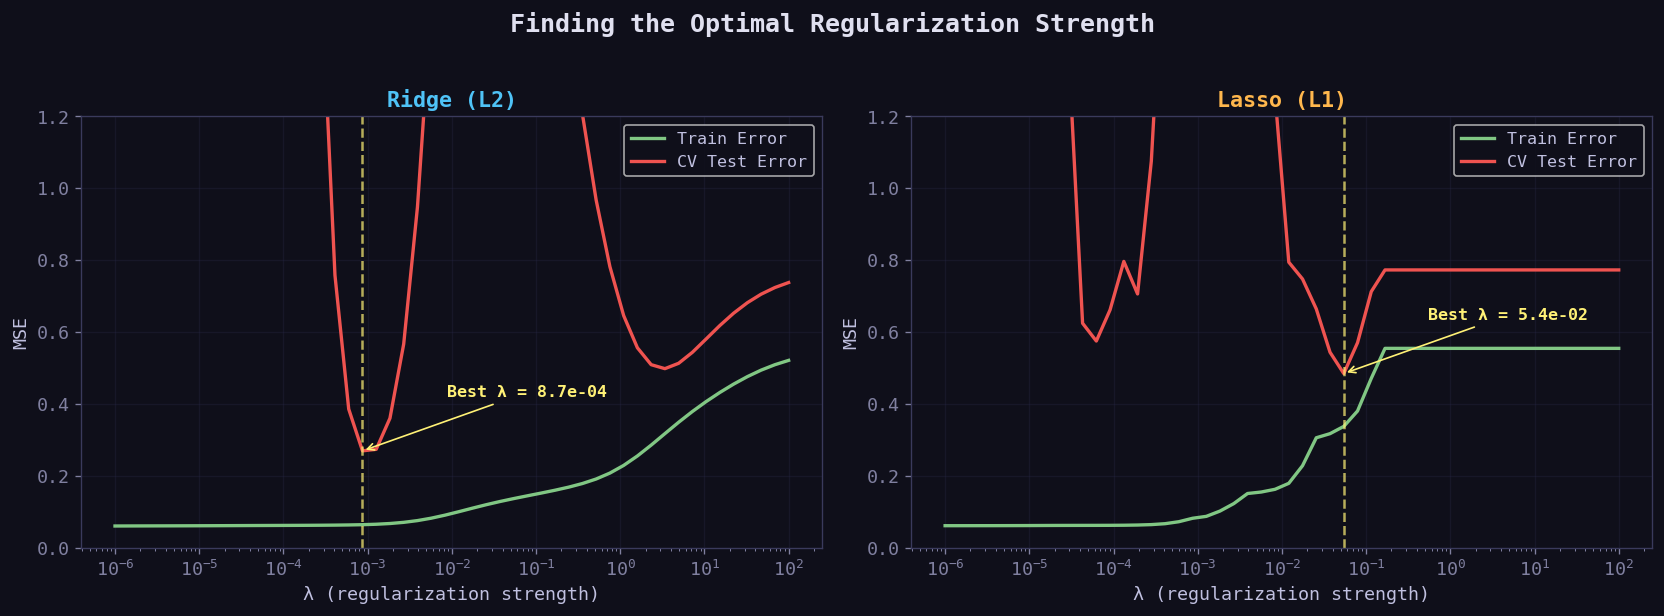


🎓 You've completed the Regularization Masterclass!
   You now understand the math, code, geometry, and Bayesian views.
   Go ace that interview! 💪


In [13]:
# Final comprehensive visualization: Regularization Strength vs Model Behavior
np.random.seed(42)
n = 30
X = np.sort(np.random.uniform(0, 1, n))
y_true = np.sin(2 * np.pi * X)
y = y_true + np.random.normal(0, 0.3, n)
X_plot = np.linspace(0, 1, 300)

alphas_test = np.logspace(-6, 2, 50)
train_errors_ridge, test_errors_ridge = [], []
train_errors_lasso, test_errors_lasso = [], []

for a in alphas_test:
    for Model, t_list, te_list in [(Ridge, train_errors_ridge, test_errors_ridge),
                                     (Lasso, train_errors_lasso, test_errors_lasso)]:
        model = make_pipeline(PolynomialFeatures(12), Model(alpha=a, max_iter=50000))
        # Use cross-validation score as proxy for test error
        model.fit(X.reshape(-1, 1), y)
        train_pred = model.predict(X.reshape(-1, 1))
        t_list.append(np.mean((y - train_pred)**2))
        
        cv_scores = cross_val_score(model, X.reshape(-1, 1), y, cv=5, scoring='neg_mean_squared_error')
        te_list.append(-cv_scores.mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, train_err, test_err, color in [
    (axes[0], 'Ridge (L2)', train_errors_ridge, test_errors_ridge, C['blue']),
    (axes[1], 'Lasso (L1)', train_errors_lasso, test_errors_lasso, C['orange'])
]:
    ax.plot(alphas_test, train_err, c=C['green'], lw=2, label='Train Error')
    ax.plot(alphas_test, test_err, c=C['red'], lw=2, label='CV Test Error')
    
    best_idx = np.argmin(test_err)
    best_alpha = alphas_test[best_idx]
    ax.axvline(best_alpha, ls='--', c=C['yellow'], alpha=0.7)
    ax.annotate(f'Best λ = {best_alpha:.1e}', xy=(best_alpha, test_err[best_idx]),
                xytext=(best_alpha * 10, test_err[best_idx] + 0.15),
                fontsize=10, color=C['yellow'], fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=C['yellow']))
    
    ax.set_xscale('log')
    ax.set_xlabel('λ (regularization strength)', fontsize=11)
    ax.set_ylabel('MSE', fontsize=11)
    ax.set_title(name, fontsize=13, fontweight='bold', color=color)
    ax.legend(fontsize=10)
    ax.set_ylim(0, 1.2)

fig.suptitle('Finding the Optimal Regularization Strength',
             fontsize=15, fontweight='bold', color=C['white'], y=1.02)
plt.tight_layout()
plt.show()

print("\n🎓 You've completed the Regularization Masterclass!")
print("   You now understand the math, code, geometry, and Bayesian views.")
print("   Go ace that interview! 💪")